## PA005 - High Value Customer Identification (Rankers)

# 0.0 Imports

In [1]:
import math
import inflection
import numpy        as np
import pandas       as pd
import seaborn      as sns
import umap.umap_   as umap

from itables                import show
from matplotlib             import pyplot as plt
from IPython.display        import Markdown, display
from sqlalchemy             import create_engine, text

from sklearn.decomposition  import PCA
from sklearn.cluster        import DBSCAN
from sklearn.cluster        import KMeans
from sklearn.mixture        import GaussianMixture
from sklearn.ensemble       import RandomForestRegressor
from sklearn.cluster        import AgglomerativeClustering


from sklearn.metrics        import silhouette_score, silhouette_samples
from yellowbrick.cluster    import SilhouetteVisualizer

/home/pollon/.pyenv/versions/pa005_rankers/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1 Helper Functions

In [2]:
def vscode_settings():
    plt.style.use('bmh')
    
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 14
    plt.rcParams['font.family'] = 'DejaVu Sans'
    
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
    sns.set_palette("Set2")

vscode_settings()       

In [3]:
def plot_settings():
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Base limpa
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Tamanho equilibrado
    plt.rcParams['figure.figsize'] = (14, 8)
    plt.rcParams['figure.dpi'] = 120
    
    # Fonte segura
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12
    
    # Grid mais leve
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'
    
    # Remove bordas desnecessárias
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    
    # Paleta mais profissional
    sns.set_palette("colorblind")
    
    # Pandas display
    pd.options.display.max_columns = None
    pd.options.display.max_rows = 200
    pd.set_option('display.expand_frame_repr', False)

plot_settings()

In [4]:
def show_hypothesis(metric, result):
    texto = f"""

**Metric:** {metric}  

**Result:** {result}  

---
"""
    display(Markdown(texto))

In [5]:
def plot_compare(df, col, title):
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x='is_champion', y=col)
    plt.title(title)
    plt.xlabel('')
    plt.ylabel(col)
    plt.xticks([0,1], ['Others', 'Rankers'])
    plt.tight_layout()
    plt.show()

## 0.2 Load Dataset

In [6]:
df_raw = (
    pd.read_csv(
        '../data/Ecommerce.csv',
        encoding='latin1'
    )
    .loc[:, lambda df: ~df.columns.str.contains('^Unnamed')]
)

# 1.0 Data Description

In [7]:
df1 = df_raw

## 1.1 Rename columns

In [8]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
cols_old = df1.columns

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new
df1.sample()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
196043,553767,84375,SET OF 20 KIDS COOKIE CUTTERS,1,17-May-17,4.13,NaN,United Kingdom


## 1.2 Data Dimensions

In [10]:
df1.shape

(541909, 8)

## 1.3 Data types

In [11]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

## 1.4 Check NA

In [12]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

## 1.5 Replace NA

### <font color='red'> 1.5.1 NA verify

Tentativa de recuperar os dados inserindo customers sinteticos, mas atrapalharia o custer, pois a frequencia desses clientes seria 1 e nao ajudaria. Validado no código abaixo que nao há invoice_no iguais para invoice_date diferentes.

3710 invoices_no com customers zerados, representando 135080 linhas vazias 'irrecuperáveis', melhor forma é remover (25%)

In [13]:
(df1
 .groupby('invoice_no')['invoice_date']
 .nunique()
 .loc[lambda x: x > 1]
)

Series([], Name: invoice_date, dtype: int64)

In [14]:
df1.groupby('invoice_no')['customer_id'].nunique(dropna=True).value_counts()

customer_id
1    22190
0     3710
Name: count, dtype: int64

In [15]:
# quantidade antes
before = len(df1)

# remover linhas sem customer_id
df1 = df1.dropna(subset=['customer_id']).copy()

# quantidade depois
after = len(df1)

# quantidade removida
removed = before - after

print(f'Linhas removidas: {removed}')
print(f'Linhas restantes: {after}')

Linhas removidas: 135080
Linhas restantes: 406829


In [16]:
df1.isna().sum()

invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
dtype: int64

## 1.6 Change dtypes

In [17]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

In [18]:
# invoice date

df1['invoice_date'] = pd.to_datetime(df1['invoice_date'], format='%d-%b-%y')

#customer_id

df1['customer_id']  = df1['customer_id'].astype(int)

In [19]:
df1.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

## 1.7 Descriptive Statistics

In [20]:
df1.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

In [21]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64'])

### 1.7.1 Numerical Attributes

In [22]:
# central tendency - mean, median
ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T 
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T 

# dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(np.min)).T
d3 = pd.DataFrame (num_attributes.apply(np.max)).T
d4 = pd.DataFrame (num_attributes.apply( lambda x: x.max() - x.min())).T
d5 = pd.DataFrame (num_attributes.apply( lambda x: x.skew())).T
d6 = pd.DataFrame (num_attributes.apply( lambda x: x.kurtosis())).T

# concatenate
m = pd.concat ([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,quantity,-80995.0,80995.0,161990.0,12.061303,5.00,248.693064,0.182663,94317.563673
1,unit_price,0.0,38970.0,38970.0,3.460471,1.95,69.315077,452.219019,246924.542988
2,customer_id,12346.0,18287.0,5941.0,15287.690570,15152.00,1713.598197,0.029835,-1.179982


### 1.7.2 Categorical Attributes

In [23]:
cat_attributes.head()

,invoice_no,stock_code,description,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,536365,71053,WHITE METAL LANTERN,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom


In [24]:
# INVOICE_NO

#cat_attributes['invoice_no'].astype(int)
#invalid literal for int() with base 10: 'C536379'

# filtra invoices que possuem qualquer caractere não numérico
df_matches = cat_attributes[
    cat_attributes['invoice_no'].str.contains(r'[^0-9]', regex=True, na=False)
]

# quantidade de invoices
quantidade = len(df_matches)

# prefixos de letras no início do invoice
prefixos = sorted(
    set(
        df_matches['invoice_no'].str.extract(r'^([A-Za-z]+)', expand=False).dropna()
    )
)

print('Prefixos encontrados: {}'.format(prefixos))
print('Quantidade de invoice com letras: {}'.format(quantidade))

df_matches

Prefixos encontrados: ['C']
Quantidade de invoice com letras: 8905


,invoice_no,stock_code,description,country
141,C536379,D,Discount,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,United Kingdom
...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,United Kingdom
541541,C581499,M,Manual,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,United Kingdom


In [25]:
# STOCK_CODE

# filtra stock_code que possuem letras
df_matches = cat_attributes[
    cat_attributes['stock_code'].str.contains(r'[A-Za-z]', regex=True, na=False)
].drop_duplicates(subset='stock_code')

# extrai blocos de letras
prefixos = sorted(
    set(
        df_matches['stock_code'].str.extract(r'^([A-Za-z]+)', expand=False).dropna()
    )
)

quantidade = len(prefixos)
quantidade2 = df_matches['stock_code'].nunique()

print('Prefixos únicos encontrados: {}'.format(prefixos))
print('Quantidade de prefixos: {}'.format(quantidade))
print('Quantidade de stock_codes: {}'.format(quantidade2))


df_matches

Prefixos únicos encontrados: ['BANK', 'C', 'CRUK', 'D', 'DOT', 'M', 'PADS', 'POST']
Quantidade de prefixos: 8
Quantidade de stock_codes: 886


,invoice_no,stock_code,description,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom
45,536370,POST,POSTAGE,France
...,...,...,...,...
527060,580691,90214O,"LETTER ""O"" BLING KEY RING",United Kingdom
527064,580691,90214T,"LETTER ""T"" BLING KEY RING",United Kingdom
527065,580691,90214U,"LETTER ""U"" BLING KEY RING",United Kingdom
527067,580691,90214W,"LETTER ""W"" BLING KEY RING",United Kingdom


#### <font color='red'> VALIDAR POSTERIORMENTE OS PAISES, DA PRA CLUSTERIZAR SEPARADO POR UK E INTERNACIONAIS

In [26]:
# COUNTRY
print('Países únicos:{}'.format(len(cat_attributes['country'].unique())))

vc = cat_attributes['country'].value_counts()
pd.DataFrame({
    'count': vc,
    'percentage': vc / vc.sum()
})

Países únicos:37


,count,percentage
country,,
United Kingdom,361878,0.889509
Germany,9495,0.023339
France,8491,0.020871
EIRE,7485,0.018398
Spain,2533,0.006226
Netherlands,2371,0.005828
Belgium,2069,0.005086
Switzerland,1877,0.004614
Portugal,1480,0.003638


# 2.0 Feature Filtering

## 2.1 Numerical Attributes

In [27]:
df2 = df1.copy()

In [28]:
df2[df2['unit_price'] < 1][
    ['quantity','unit_price']
].sort_values('quantity', ascending=False).head(10)

,quantity,unit_price
502122,12540,0.00
421632,4800,0.21
206121,4300,0.72
97432,3906,0.82
270885,3186,0.06
433788,3000,0.32
4945,2880,0.18
201149,2700,0.42
80742,2592,0.21
87631,2400,0.94


In [29]:
df_zero_price = df2[df2['unit_price'] == 0].copy()

df_zero_desc = (
    df_zero_price
    .groupby(['stock_code','description'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

df_zero_desc

,stock_code,description,count
33,M,Manual,6
1,21786,POLKADOT RAIN HAT,1
0,21208,PASTEL COLOUR HONEYCOMB FAN,1
2,22055,MINI CAKE STAND HANGING STRAWBERY,1
3,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,1
5,22089,PAPER BUNTING VINTAGE PAISLEY,1
4,22065,CHRISTMAS PUDDING TRINKET POT,1
7,22162,HEART GARLAND RUSTIC PADDED,1
8,22167,OVAL WALL MIRROR DIAMANTE,1
9,22168,ORGANISER WOOD ANTIQUE WHITE,1


In [30]:
# REMOVER UNIT PRICE = 0

df2 = df2[df2['unit_price'] > 0].copy()

In [31]:
df2[df2['unit_price'] < 1][
    ['quantity','unit_price']
].sort_values('quantity', ascending=False).head(10)

,quantity,unit_price
421632,4800,0.21
206121,4300,0.72
97432,3906,0.82
270885,3186,0.06
433788,3000,0.32
4945,2880,0.18
201149,2700,0.42
80742,2592,0.21
32671,2400,0.94
91772,2400,0.06


## 2.2 <font color='red'>Categorial Atributes

In [32]:
# remover stock codes com caracteres

df2 = df2[df2['stock_code'].str.match(r'^\d+$', na=False)].copy()

## 2.3 Filtering

In [33]:
df_purchase = df2[~df2['invoice_no'].str.startswith('C')].copy()
df_returns = df2[df2['invoice_no'].astype(str).str.startswith('C')].copy()

In [34]:
df_returns.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2016-11-29,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2016-11-29,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2016-11-29,0.29,17548,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2016-11-29,0.29,17548,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2016-11-29,3.45,17548,United Kingdom


In [35]:
df_returns[df_returns['quantity'] > 0]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country


In [36]:
df_purchase = df_purchase[
    (df_purchase['quantity'] > 0) &
    (df_purchase['unit_price'] > 0)
].copy()

In [37]:
df_purchase.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2016-11-29,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2016-11-29,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2016-11-29,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2016-11-29,1.85,17850,United Kingdom


In [38]:
df_purchase[df_purchase['quantity'] < 0]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country


# 3.0 Feature Engineering

In [39]:
df3 = df2.copy()

In [40]:
df3[~df3['invoice_no'].str.startswith('C')].copy()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2016-11-29,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2016-11-29,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2016-11-29,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2016-11-29,1.85,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2017-12-07,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2017-12-07,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2017-12-07,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2017-12-07,4.15,12680,France


## 3.1 Feature Creation

In [41]:
df3.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2016-11-29,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2016-11-29,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2016-11-29,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2016-11-29,1.85,17850,United Kingdom


In [42]:
# data reference
df_ref = df3.drop(['invoice_no', 'stock_code', 'description',
                   'quantity', 'invoice_date', 'unit_price', 'country'], axis=1).drop_duplicates().reset_index(drop=True)
df_ref.head(10)

,customer_id
0,17850
1,13047
2,12583
3,13748
4,15100
5,15291
6,14688
7,17809
8,15311
9,16098


In [43]:
len(df_ref['customer_id'].unique())

4341

### 3.1.1 Gross Revenue

In [44]:
# Gross Revenue quantity * price = faturamento
df_purchase['gross_revenue'] = df_purchase['quantity'] * df_purchase['unit_price']

# Monetary
df_monetary = (
    df_purchase[['customer_id','gross_revenue']]
    .groupby('customer_id')
    .sum()
    .reset_index()
)

df_ref = pd.merge(df_ref, df_monetary, on='customer_id', how='left')

In [45]:
df_ref.isna().sum()

customer_id       0
gross_revenue    27
dtype: int64

In [46]:
df_ref = df_ref.dropna()

### 3.1.2 Recency

In [47]:
# Recency - Last day purchase
df_recency = (
    df_purchase[['customer_id', 'invoice_date']]
    .groupby('customer_id')
    .max()
    .reset_index()
)

df_recency['recency_days'] = (
    df_purchase['invoice_date'].max() - df_recency['invoice_date']
).dt.days

df_recency = df_recency[['customer_id', 'recency_days']].copy()

df_ref = pd.merge(df_ref, df_recency, on='customer_id', how='left')


### 3.1.3 Frequency

In [48]:
# Frequency - Frequência de pedidos
df_freq = (
    df_purchase
    .groupby('customer_id')['invoice_no']
    .nunique()
    .reset_index()
    .rename(columns={'invoice_no': 'frequency'})
)

df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')

### 3.1.4 AVG ticket

In [49]:
# AVG ticket
df_order_value = (
    df_purchase
    .groupby(['customer_id','invoice_no'])['gross_revenue']
    .sum()
    .reset_index()
)

df_avg_ticket = (
    df_order_value
    .groupby('customer_id')['gross_revenue']
    .mean()
    .reset_index()
    .rename(columns={'gross_revenue':'avg_ticket'})
)

df_ref = pd.merge(df_ref, df_avg_ticket, on='customer_id', how='left')

### 3.1.5 Customer Lifetime  (Tempo de atividade do customer ou relacionamento com a loja {ultima-primeira compra})

In [50]:
df_first_purchase = (
    df_purchase
    .groupby('customer_id')['invoice_date']
    .min()
    .reset_index()
    .rename(columns={'invoice_date':'first_purchase'})
)

df_last_purchase = (
    df_purchase
    .groupby('customer_id')['invoice_date']
    .max()
    .reset_index()
    .rename(columns={'invoice_date':'last_purchase'})
)

df_lifetime = pd.merge(df_first_purchase, df_last_purchase, on='customer_id')

df_lifetime['customer_lifetime_days'] = (
    df_lifetime['last_purchase'] - df_lifetime['first_purchase']
).dt.days

df_ref = pd.merge(df_ref, df_lifetime[['customer_id','customer_lifetime_days']], on='customer_id', how='left')

### 3.1.6 Revenue Velocity

In [51]:
# REVENUE VELOCITY

df_ref['revenue_velocity'] = (
    df_ref['gross_revenue'] / np.maximum(df_ref['customer_lifetime_days'], 1)
)

### 3.1.7 Item Velocity

In [52]:
# ITEM VELOCITY
df_total_items = (
    df_purchase
    .groupby('customer_id')['quantity']
    .sum()
    .reset_index()
    .rename(columns={'quantity':'total_items'})
)

df_ref = pd.merge(df_ref, df_total_items, on='customer_id', how='left')


df_ref['items_velocity'] = (
    df_ref['total_items'] / (df_ref['customer_lifetime_days'] + 30)
)

### 3.1.8 Basket Size (Tamanho do carrinho)

In [53]:
# BASKET SIZE
df_items_order = (
    df_purchase
    .groupby(['customer_id','invoice_no'])['quantity']
    .sum()
    .reset_index()
)

df_basket_size = (
    df_items_order
    .groupby('customer_id')['quantity']
    .mean()
    .reset_index()
    .rename(columns={'quantity':'basket_size'})
)

df_ref = pd.merge(df_ref, df_basket_size, on='customer_id', how='left')

### 3.1.9 Unique Products (Quantidade de produtos unicos comprados)

In [54]:
# Unique Products

df_unique_products = (
    df_purchase
    .groupby('customer_id')['stock_code']
    .nunique()
    .reset_index()
    .rename(columns={'stock_code':'unique_products'})
)

df_ref = df_ref.merge(df_unique_products, on='customer_id', how='left')

### 3.1.10 Product Loyalty  (Quantas x o customer compra os mesmos produtos)

In [55]:
df_ref['product_loyalty'] = (
    df_ref['total_items'] / df_ref['unique_products']
)

df_ref['product_loyalty'] = (
    df_ref['product_loyalty']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

### 3.1.11 AVG Recency Days - Tempo médio entre compras

In [56]:
df_purchase_sorted = df_purchase.sort_values(['customer_id', 'invoice_date'])

df_purchase_sorted['days_between'] = df_purchase_sorted.groupby('customer_id')['invoice_date'].diff().dt.days

df_avg_recency = (
    df_purchase_sorted
    .groupby('customer_id')['days_between']
    .mean()
    .reset_index()
    .rename(columns={'days_between': 'avg_recency_days'})
)

# Merge com df_ref
df_ref = pd.merge(df_ref, df_avg_recency, on='customer_id', how='left')

# Substituir NaN (clientes com 1 compra) pelo lifetime_days
df_ref['avg_recency_days'] = df_ref['avg_recency_days'].fillna(df_ref['customer_lifetime_days'])

### 3.1.12 Returns

In [57]:
df_returns['return_revenue'] = df_returns['quantity'] * df_returns['unit_price']

df_return_value = (
    df_returns.groupby('customer_id')['return_revenue']
    .sum()
    .abs()
    .reset_index()
    .rename(columns={'return_revenue':'return_value'})
)

df_return_orders = (
    df_returns.groupby('customer_id')['invoice_no']
    .nunique()
    .reset_index()
    .rename(columns={'invoice_no':'return_orders'})
)

df_returns_features = pd.merge(
    df_return_value,
    df_return_orders,
    on='customer_id',
    how='outer'
)

df_ref = pd.merge(
    df_ref,
    df_returns_features,
    on='customer_id',
    how='left'
)


In [58]:
df_ref.isna().sum()

customer_id                  0
gross_revenue                0
recency_days                 0
frequency                    0
avg_ticket                   0
customer_lifetime_days       0
revenue_velocity             0
total_items                  0
items_velocity               0
basket_size                  0
unique_products              0
product_loyalty              0
avg_recency_days             0
return_value              2864
return_orders             2864
dtype: int64

#### 3.1.12.1 Remove Returns NA

In [59]:
df_ref[['return_value','return_orders']] = df_ref[['return_value','return_orders']].fillna(0)

### 3.1.13 Return Value Ratio

In [60]:
# CRIAR O RETURN RATE COM AS DEVOLUCOES E FREQUENCIA

df_ref['return_rate'] = df_ref['return_orders'] / (df_ref['return_orders'] + df_ref['frequency'])

# CRIAR O RETURN RATE VALUE RATIO
df_ref['return_value_ratio'] = np.where(
    df_ref['gross_revenue'] > 0,
    df_ref['return_value'] / df_ref['gross_revenue'],
    0
)


df_ref['return_value_ratio'] = df_ref['return_value_ratio'].clip(0,1)
df_ref['return_value_ratio'] = df_ref['return_value_ratio'].fillna(0)

### 3.1.14 Net Revenue

In [61]:
df_ref.sort_values('return_value_ratio', ascending=False).head(20)

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,customer_lifetime_days,revenue_velocity,total_items,items_velocity,basket_size,unique_products,product_loyalty,avg_recency_days,return_value,return_orders,return_rate,return_value_ratio
4276,12558,228.76,7,1,228.760000,0,228.760000,162,5.400000,162.000000,9,18.000000,0.000000,228.76,1.0,0.500000,1.000000
3725,12607,1508.81,60,1,1508.810000,0,1508.810000,1183,39.433333,1183.000000,96,12.322917,0.000000,1508.81,1.0,0.500000,1.000000
3672,14792,4.25,63,1,4.250000,0,4.250000,1,0.033333,1.000000,1,1.000000,0.000000,4.25,1.0,0.500000,1.000000
1023,13672,60.84,301,2,30.420000,31,1.962581,36,0.590164,18.000000,1,36.000000,31.000000,60.84,3.0,0.600000,1.000000
1140,12346,77183.60,325,1,77183.600000,0,77183.600000,74215,2473.833333,74215.000000,1,74215.000000,0.000000,77183.60,1.0,0.500000,1.000000
3436,16878,13.30,84,1,13.300000,0,13.300000,12,0.400000,12.000000,3,4.000000,0.000000,13.30,1.0,0.500000,1.000000
124,16546,787.15,290,2,393.575000,82,9.599390,549,4.901786,274.500000,25,21.960000,3.416667,883.08,1.0,0.333333,1.000000
3590,13364,123.36,71,1,123.360000,0,123.360000,63,2.100000,63.000000,9,7.000000,0.000000,123.36,1.0,0.500000,1.000000
3427,14557,788.38,85,1,788.380000,0,788.380000,510,17.000000,510.000000,16,31.875000,0.000000,788.38,1.0,0.500000,1.000000
4062,18274,160.92,30,1,160.920000,0,160.920000,84,2.800000,84.000000,10,8.400000,0.000000,160.92,1.0,0.500000,1.000000


In [62]:
# tamanho inicial
before = len(df_ref)

# criar net revenue
df_ref['net_revenue'] = df_ref['gross_revenue'] - df_ref['return_value']

# condições de remoção
cond_net = df_ref['net_revenue'] <= 0
cond_return = df_ref['return_value_ratio'] >= 0.95

# contagem por condição
removed_net = cond_net.sum()
removed_return = cond_return.sum()

# clientes removidos (considerando as duas condições juntas)
df_ref = df_ref[~(cond_net | cond_return)]

after = len(df_ref)
removed_total = before - after

print(
    f"Foram removidos {removed_total} customers ({removed_total/before:.2%} do dataset).\n"
    f"- {removed_net} tinham net_revenue <= 0 (compras totalmente canceladas).\n"
    f"- {removed_return} tinham return_value_ratio >= 0.95 (devolução quase total).\n"
    f"Dataset final: {after} customers."
)

Foram removidos 15 customers (0.35% do dataset).
- 11 tinham net_revenue <= 0 (compras totalmente canceladas).
- 15 tinham return_value_ratio >= 0.95 (devolução quase total).
Dataset final: 4299 customers.


In [63]:
df_ref.describe()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,customer_lifetime_days,revenue_velocity,total_items,items_velocity,basket_size,unique_products,product_loyalty,avg_recency_days,return_value,return_orders,return_rate,return_value_ratio,net_revenue
count,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000,4299.000000
mean,15296.017679,1805.698355,92.227727,4.234008,349.437388,130.580833,146.948972,1068.794371,6.628548,212.987055,56.639451,32.965906,3.388795,44.574894,0.739707,0.095573,0.017066,1761.123461
std,1718.529009,7967.587789,100.344623,7.544788,455.696692,132.005084,722.172096,4489.230029,14.747334,292.930598,77.060076,205.777721,10.793229,402.580186,1.916336,0.158347,0.057513,7820.981423
min,12347.000000,4.950000,0.000000,1.000000,4.950000,0.000000,0.096231,1.000000,0.033333,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.950000
25%,13814.500000,271.905000,17.000000,1.000000,161.265000,0.000000,5.454837,145.500000,1.851903,84.236111,15.000000,6.798991,0.000000,0.000000,0.000000,0.000000,0.000000,265.565000
50%,15291.000000,619.780000,50.000000,2.000000,261.270000,93.000000,15.351346,354.000000,3.766667,148.647059,33.000000,11.418605,1.152941,0.000000,0.000000,0.000000,0.000000,605.810000
75%,16772.000000,1497.065000,142.000000,5.000000,393.468846,252.000000,157.035000,919.000000,7.066667,251.000000,71.000000,18.000000,3.239116,12.750000,1.000000,0.166667,0.009146,1465.445000
max,18287.000000,265106.920000,373.000000,199.000000,13305.500000,373.000000,39916.500000,189631.000000,495.120104,7824.000000,1550.000000,8000.000000,350.000000,14761.900000,44.000000,0.750000,0.859829,264746.920000


In [64]:
df_ref.skew()

customer_id                0.003759
gross_revenue             21.843647
recency_days               1.246794
frequency                 11.822289
avg_ticket                11.482313
customer_lifetime_days     0.454667
revenue_velocity          41.140327
total_items               23.265735
items_velocity            14.431823
basket_size                9.428584
unique_products            6.454395
product_loyalty           22.769000
avg_recency_days          15.433632
return_value              26.127123
return_orders              9.288569
return_rate                1.538227
return_value_ratio         6.806063
net_revenue               22.475426
dtype: float64

# 4.0 EDA

In [65]:
df4 = df_ref.copy()

## 4.1 ExtraTress Embedding

In [66]:
df4.columns

Index(['customer_id', 'gross_revenue', 'recency_days', 'frequency',
       'avg_ticket', 'customer_lifetime_days', 'revenue_velocity',
       'total_items', 'items_velocity', 'basket_size', 'unique_products',
       'product_loyalty', 'avg_recency_days', 'return_value', 'return_orders',
       'return_rate', 'return_value_ratio', 'net_revenue'],
      dtype='object')

In [67]:
X = df4.drop(['customer_id', 'gross_revenue'], axis=1)
y = df4['gross_revenue']

In [68]:
#from boruta import BorutaPy
#from sklearn.ensemble import RandomForestRegressor

# 1. Boruta (.values)
#X_boruta = X.values
#y_boruta = y.values

# 2. Define o RandomForest para o Boruta
#rf = RandomForestRegressor(n_jobs=-1, max_depth=20)

# 3. Define o algoritmo
#boruta = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=42)

# 4. Fit
#boruta.fit(X_boruta, y_boruta)

# 5. Resultados
#features_selecionadas = X.columns[boruta.support_].tolist()
#features_duvidosas = X.columns[boruta.support_weak_].tolist()

#print(f"Selecionadas: {features_selecionadas}")
#print(f"Duvidosas (Area Verde): {features_duvidosas}")


In [69]:
features_validas = ['revenue_velocity', 'total_items', 'items_velocity', 'return_orders', 'product_loyalty']
X = X[features_validas].copy()

In [70]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

#rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X,y)

df_leafs = pd.DataFrame(rf_model.apply(X))

# One-hot
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
leafs_encoded = ohe.fit_transform(df_leafs)

/home/pollon/.pyenv/versions/pa005_rankers/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


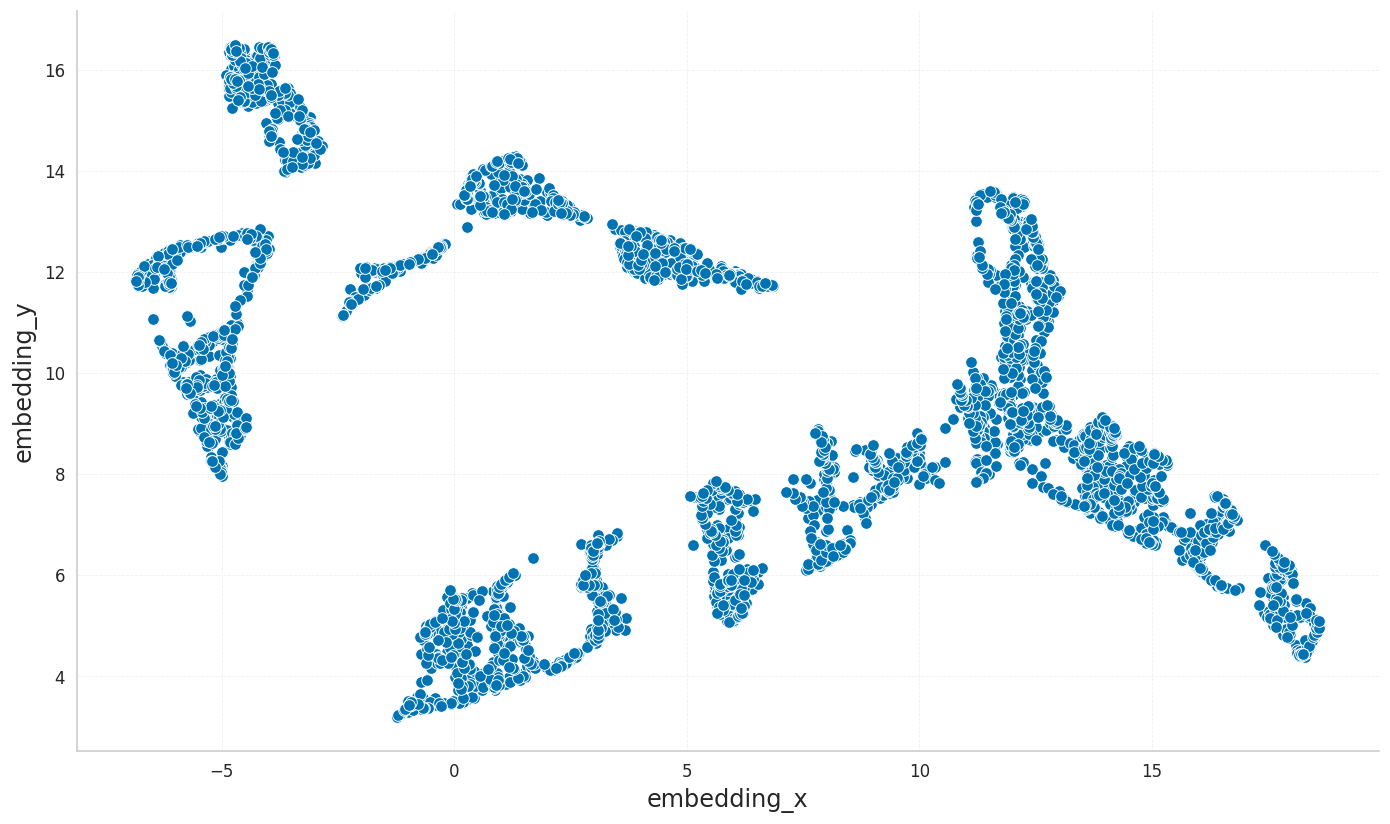

In [76]:
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(leafs_encoded)

df_tree = pd.DataFrame()
df_tree['embedding_x'] = embedding[:, 0]
df_tree['embedding_y'] = embedding[:, 1]

sns.scatterplot(
    x='embedding_x',
    y='embedding_y',
    data=df_tree
)

df_tree.to_csv('../src/data/tree_based_embedding.csv', index=False)

# 5.0 Data Preparation

In [77]:
df5 = df4.copy()

# 7.0 Hyperparameter Fine-Tunning

In [190]:
df_tree.head()

,embedding_x,embedding_y
0,17.128658,1.044344
1,17.637739,-4.587897
2,12.453226,-15.510163
3,10.140696,13.362621
4,-0.102549,16.517117


In [166]:
clusters_tree = list(range(2, 21))

## 7.1 KMeans

### 7.1.3 Silhouette Analysis - Embedding Three

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

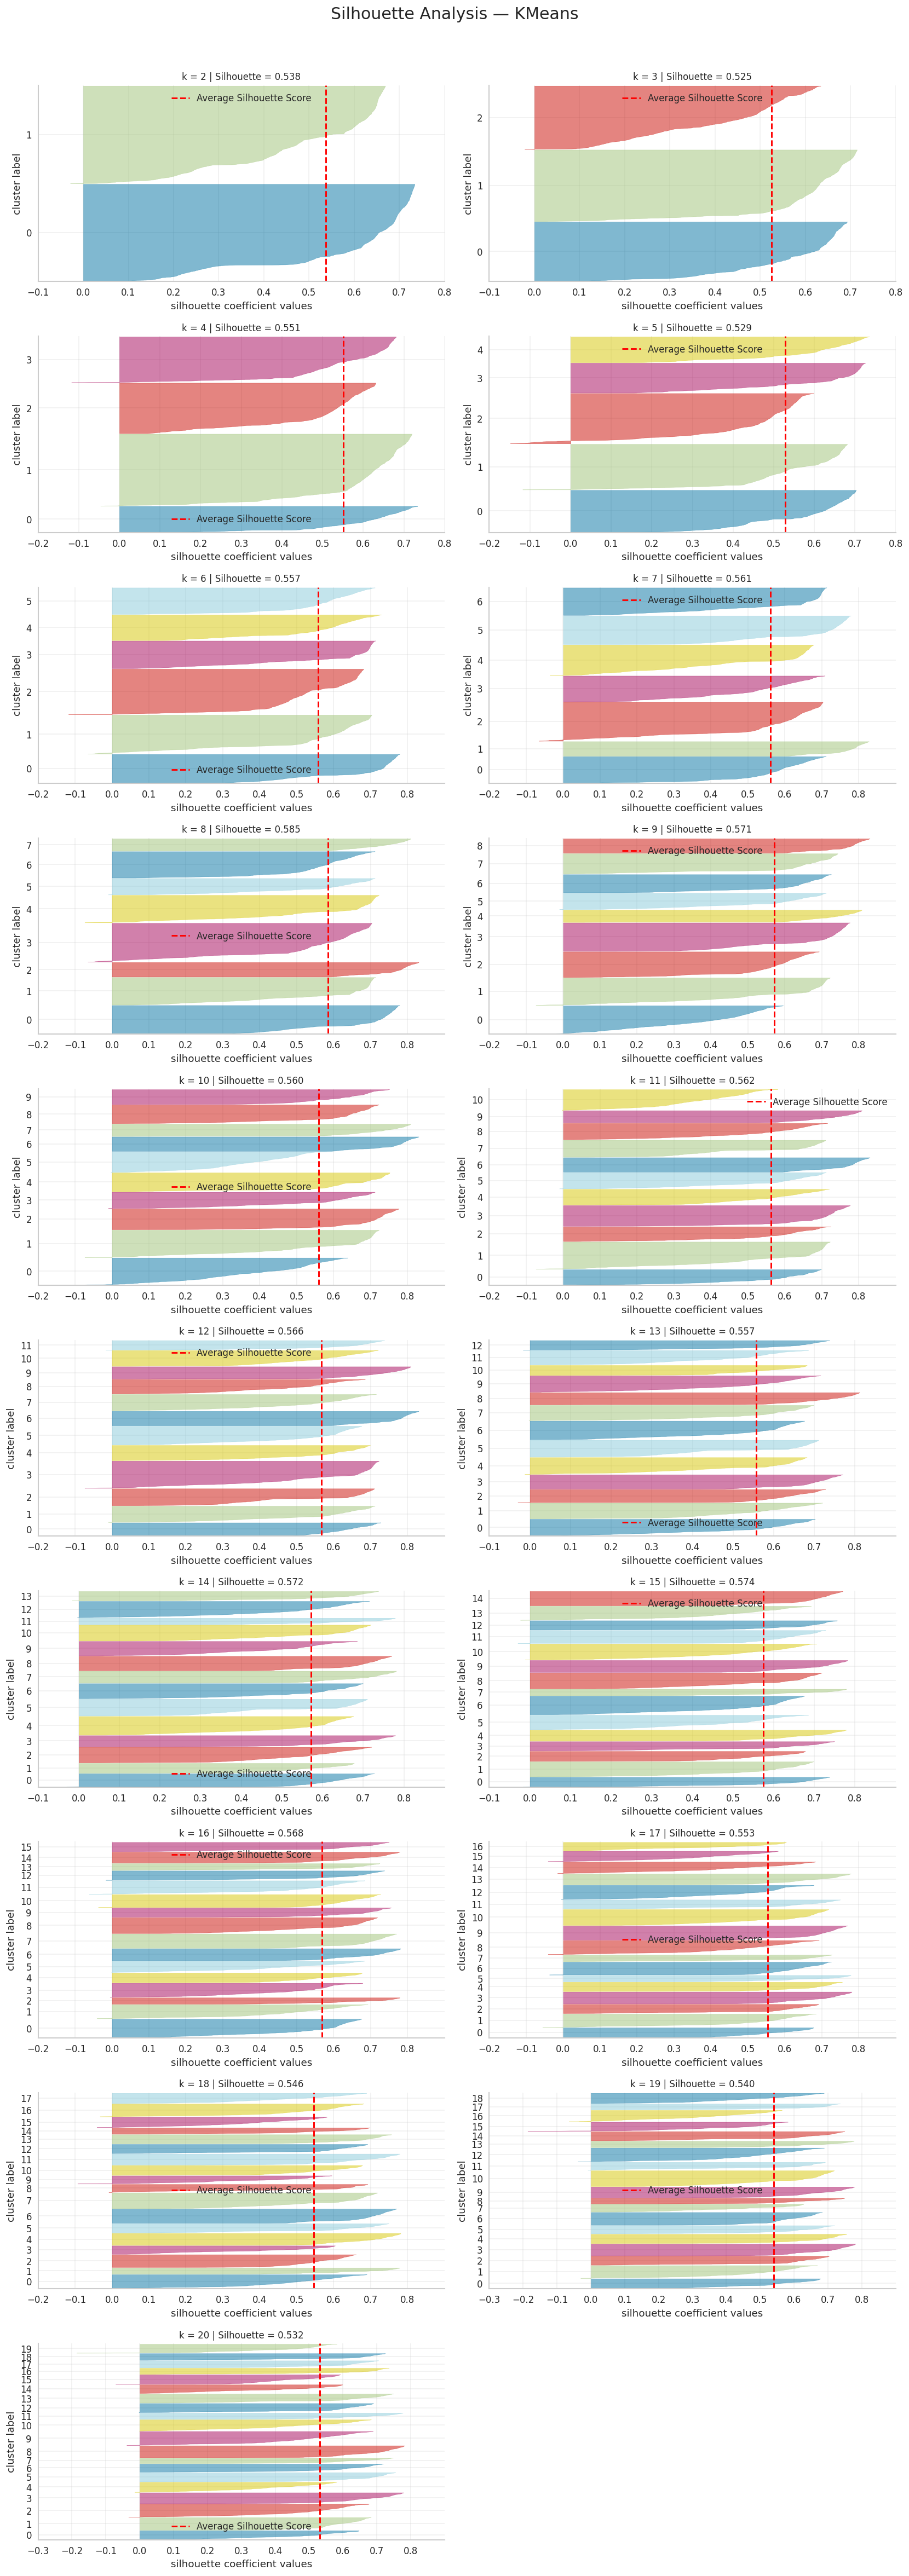

In [177]:
n_plots = len(clusters_tree)

n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))

axes = axes.flatten()

sil_kmeans_embedding = {}

for i, k in enumerate(clusters_tree):
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=50,
        max_iter=500,
        random_state=42
    )
    
    labels = km.fit_predict(df_tree.values)
    score = silhouette_score(df_tree.values, labels)
    sil_kmeans_embedding[k] = score

    visualizer = SilhouetteVisualizer(
        km,
        colors='yellowbrick',
        ax=axes[i],
        force_model=True
    )
    
    visualizer.fit(df_tree.values)
    visualizer.finalize()
    axes[i].set_title(f"k = {k} | Silhouette = {score:.3f}", fontsize=10)

# remove eixos vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Silhouette Analysis — KMeans", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 7.2 GMM

### 7.2.1 Silhouette Analysis - Embedding Three

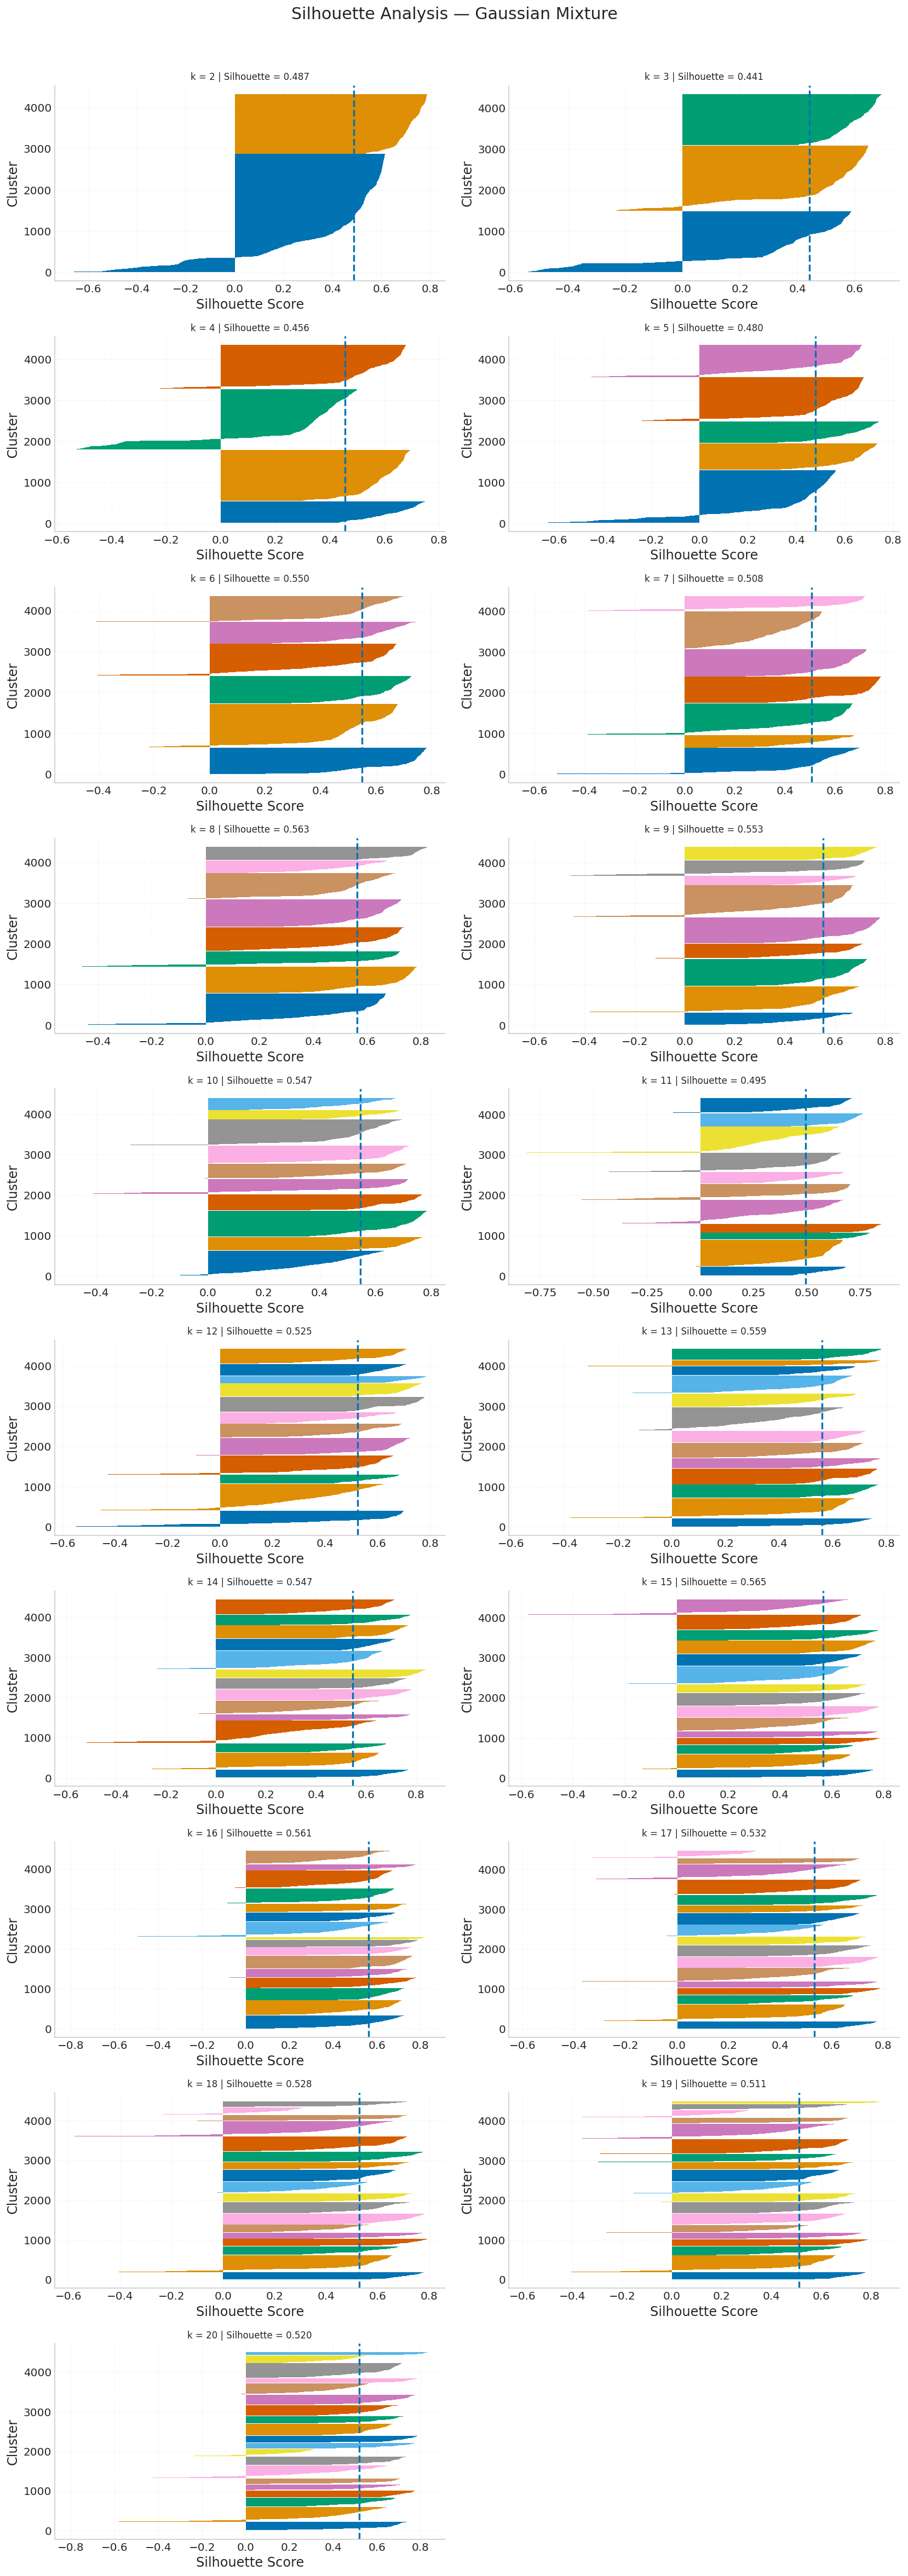

In [168]:
n_plots = len(clusters_tree)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

sil_gaussian_embedding = {}

for i, k in enumerate(clusters_tree):
    
    gm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=10,
        max_iter=300,
        init_params='kmeans',
        random_state=42
    )
    
    labels = gm.fit_predict(df_tree)
    score = silhouette_score(df_tree, labels)
    sil_gaussian_embedding[k] = score

    ax = axes[i]

    # silhouette por cluster
    sample_scores = silhouette_samples(df_tree, labels)
    y_lower = 10

    for cluster in range(k):
        cluster_scores = np.sort(sample_scores[labels == cluster])
        size = cluster_scores.shape[0]
        y_upper = y_lower + size

        ax.barh(
            range(y_lower, y_upper),
            cluster_scores,
            height=1.0
        )

        y_lower = y_upper + 10

    ax.axvline(score, linestyle='--')
    ax.set_title(f"k = {k} | Silhouette = {score:.3f}", fontsize=10)
    ax.set_xlabel("Silhouette Score")
    ax.set_ylabel("Cluster")

# remove eixos vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Silhouette Analysis — Gaussian Mixture", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 7.3 H-Clustering

### 7.3.2 Silhouette Analysis - Embedding Three

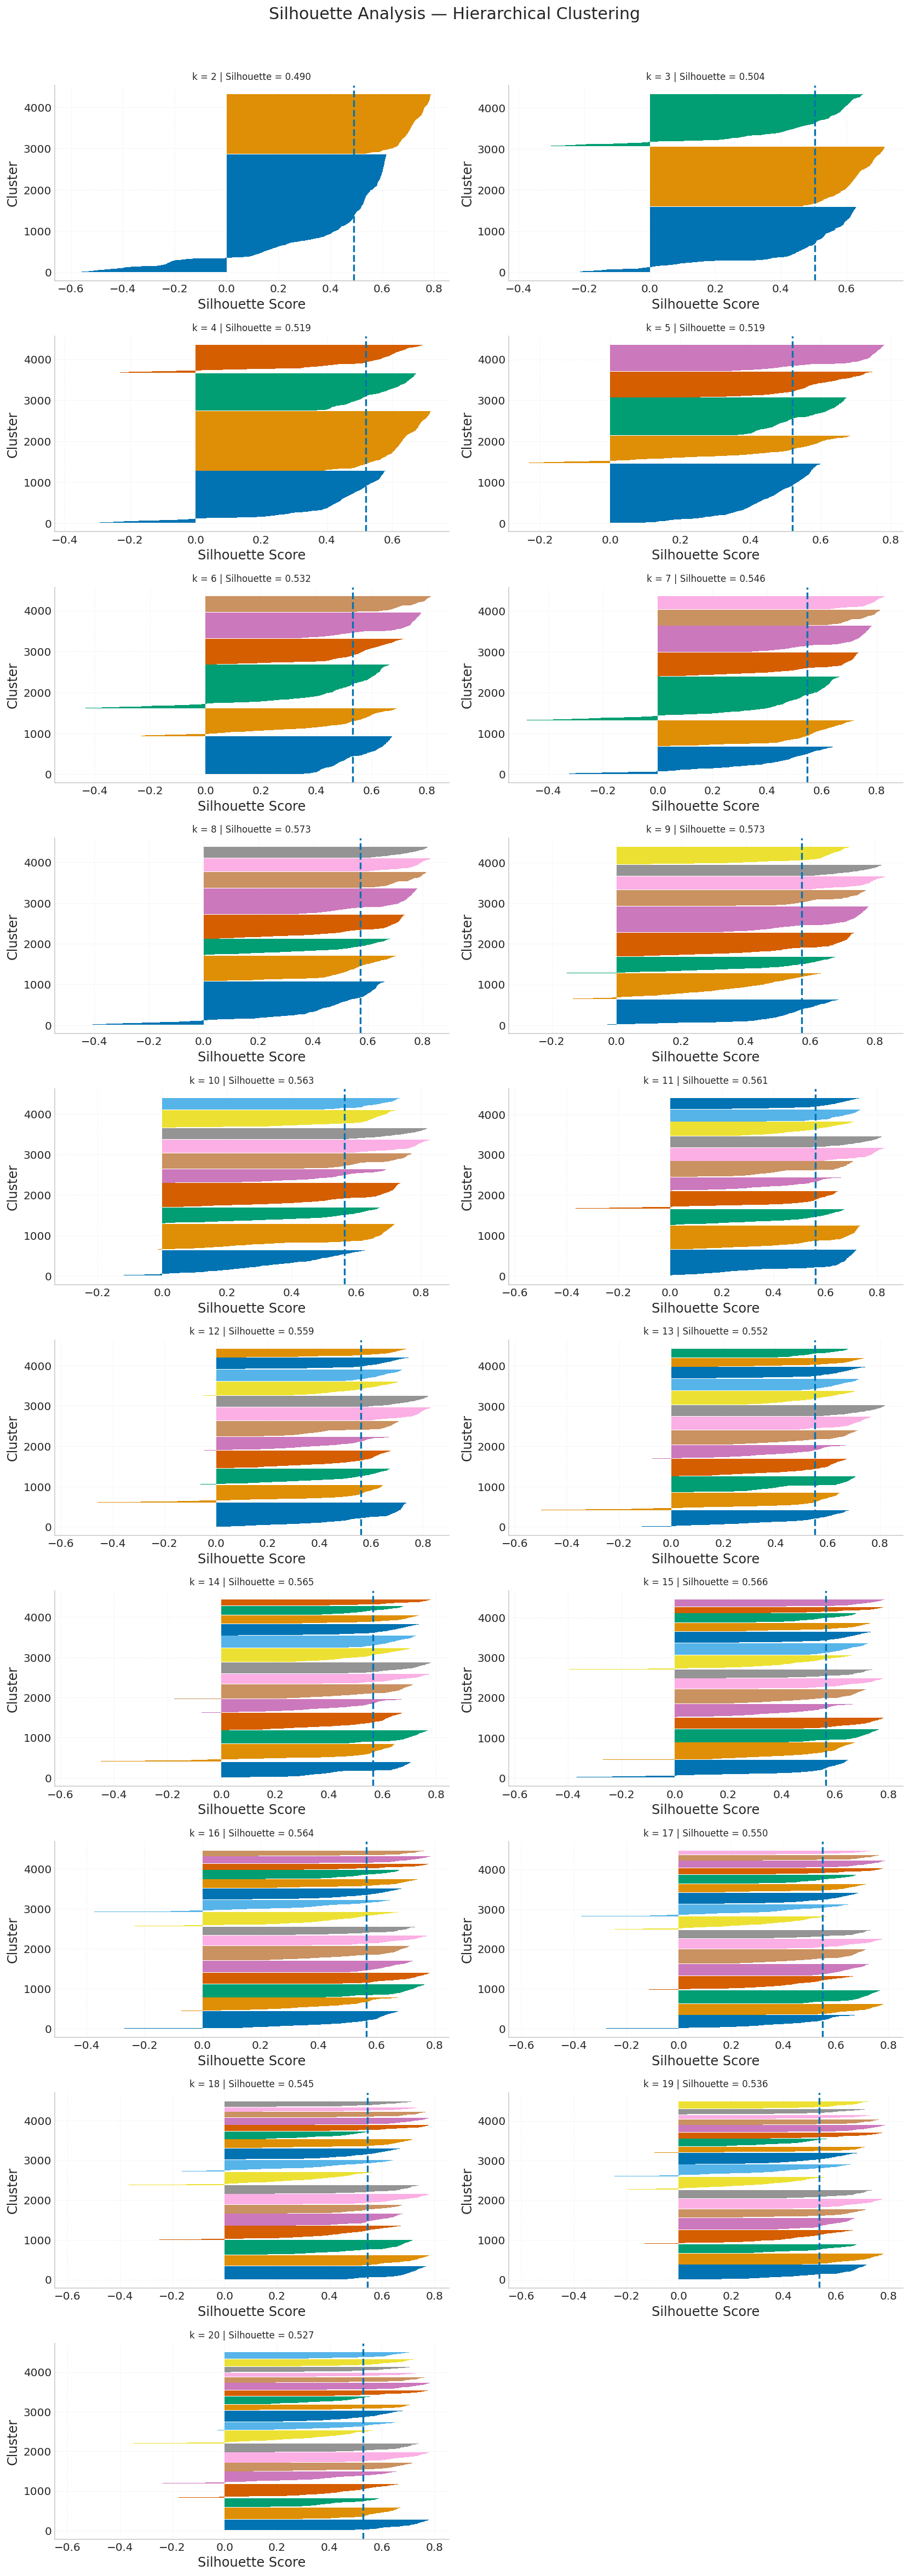

In [169]:
n_plots = len(clusters_tree)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

sil_hclust_embedding = {}

for i, k in enumerate(clusters_tree):
    
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward',          
        metric='euclidean'
    )
    
    labels = hc.fit_predict(df_tree)
    score = silhouette_score(df_tree, labels)
    sil_hclust_embedding[k] = score

    ax = axes[i]

    # silhouette por cluster
    sample_scores = silhouette_samples(df_tree, labels)
    y_lower = 10

    for cluster in range(k):
        cluster_scores = np.sort(sample_scores[labels == cluster])
        size = cluster_scores.shape[0]
        y_upper = y_lower + size

        ax.barh(
            range(y_lower, y_upper),
            cluster_scores,
            height=1.0
        )

        y_lower = y_upper + 10

    ax.axvline(score, linestyle='--')
    ax.set_title(f"k = {k} | Silhouette = {score:.3f}", fontsize=10)
    ax.set_xlabel("Silhouette Score")
    ax.set_ylabel("Cluster")

# remove eixos vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Silhouette Analysis — Hierarchical Clustering", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### 7.3.2.1 Dendogram

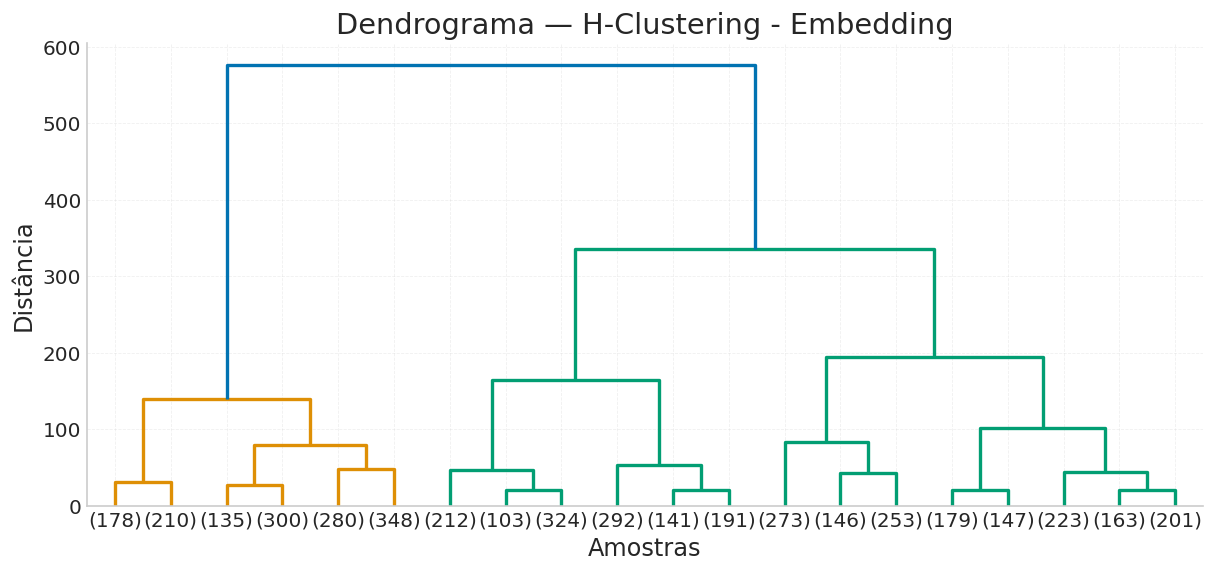

In [170]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(df_tree, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title("Dendrograma — H-Clustering - Embedding")
plt.xlabel("Amostras")
plt.ylabel("Distância")
plt.show()

## 7.4 DBScan

### 7.4.2 Silhouette Analysis - Embedding Three

In [171]:
df_tree.describe()

,embedding_x,embedding_y
count,4299.000000,4299.000000
mean,5.230930,9.292517
std,7.434216,3.353089
min,-6.846183,3.187047
25%,-0.652247,6.506922
50%,5.153856,8.895700
75%,12.028826,12.095678
max,18.602680,16.484484


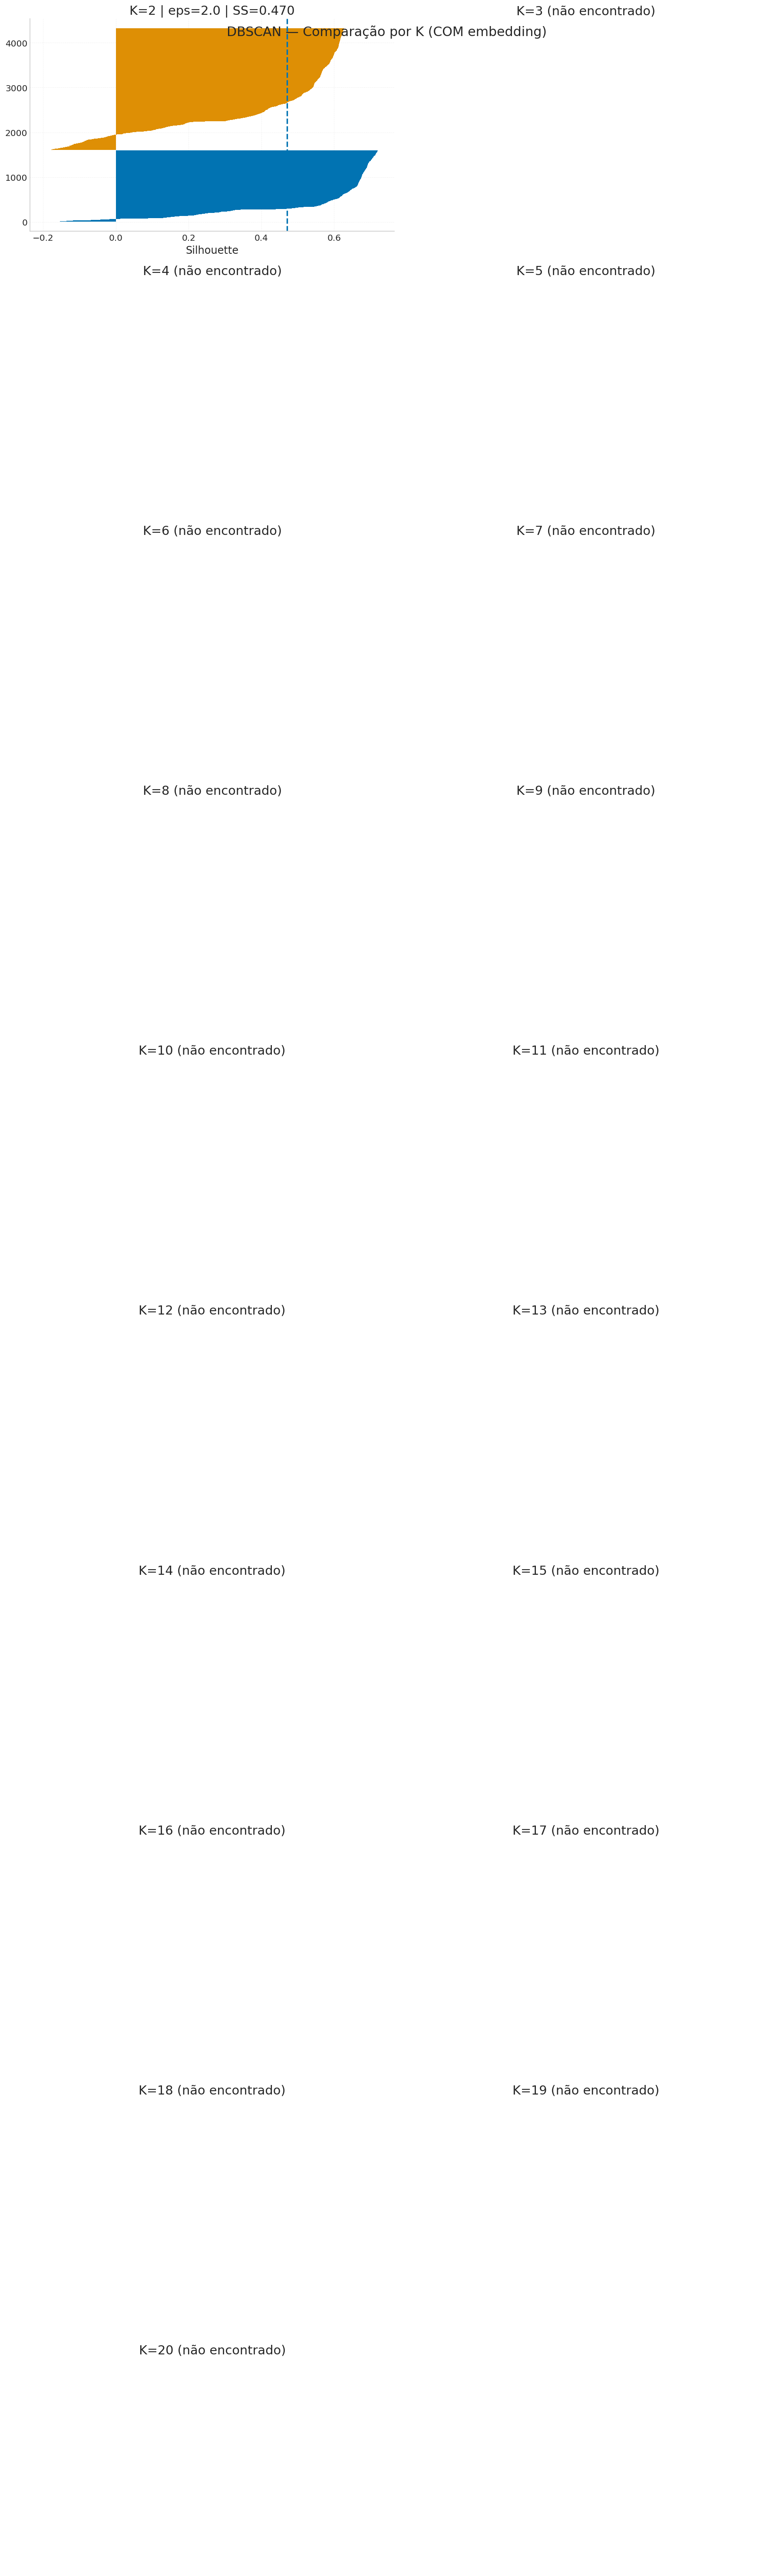

In [172]:
eps_values = np.arange(2, 30, 1.5)
min_samples_list = [5, 10, 15, 20]

best_per_k_emb = {}
best_overall_score = -1
best_overall_labels = None
best_overall_eps = None
best_overall_min = None
best_overall_k = None

# ====================== TREINO ======================

for min_samples in min_samples_list:
    for eps in eps_values:
        
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(df_tree)  # 🔥 embedding aqui

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # 🔥 força seguir clusters_tree
        if n_clusters in clusters_tree:
            
            mask = labels != -1
            
            if len(set(labels[mask])) <= 1:
                continue

            score = silhouette_score(df_tree[mask], labels[mask])
            
            # melhor config por K
            if n_clusters not in best_per_k_emb or score > best_per_k_emb[n_clusters]['score']:
                best_per_k_emb[n_clusters] = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters,
                    'score': score,
                    'labels': labels.copy()
                }
            
            # melhor geral
            if score > best_overall_score:
                best_overall_score = score
                best_overall_labels = labels.copy()
                best_overall_eps = eps
                best_overall_min = min_samples
                best_overall_k = n_clusters

# ====================== PLOT POR K ======================

if not best_per_k_emb:
    print("Nenhum cluster encontrado dentro do range de K.")
else:
    
    nrows = (len(clusters_tree) + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(15, 5*nrows))
    axes = axes.flatten()
    
    for i, k in enumerate(clusters_tree):
        
        ax = axes[i]
        
        if k not in best_per_k_emb:
            ax.set_title(f"K={k} (não encontrado)")
            ax.axis('off')
            continue
        
        data = best_per_k_emb[k]
        labels = data['labels']
        mask = labels != -1
        
        sample_scores = silhouette_samples(df_tree[mask], labels[mask])
        y_lower = 10

        for cluster in sorted(set(labels[mask])):
            cluster_scores = np.sort(sample_scores[labels[mask] == cluster])
            y_upper = y_lower + len(cluster_scores)
            
            ax.barh(range(y_lower, y_upper), cluster_scores, height=1.0)
            y_lower = y_upper + 10

        ax.axvline(data['score'], linestyle='--')
        ax.set_title(f"K={k} | eps={round(data['eps'],2)} | SS={data['score']:.3f}")
        ax.set_xlabel("Silhouette")

    # remove eixos extras
    for j in range(len(clusters_tree), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("DBSCAN — Comparação por K (COM embedding)", fontsize=18)
    plt.tight_layout()
    plt.show()

## 7.5 Results

In [178]:
# ====================== DataFrame modelos com K fixo (embedding) ======================
df_results = pd.DataFrame(
    {'KMeans': sil_kmeans_embedding,
     'GMM': sil_gaussian_embedding,
     'H-Clustering': sil_hclust_embedding}
).T

df_results.columns = list(clusters_tree)
df_results = df_results.style.highlight_max(color='green', axis=1)
show(df_results, allow_html=True)

# ====================== DataFrame do DBSCAN ======================

# ====================== FILTRAR NaN ======================

ks_validos_emb = []
scores_validos_emb = []

for k in clusters_tree:
    if k in best_per_k_emb:
        ks_validos_emb.append(k)
        scores_validos_emb.append(best_per_k_emb[k]['score'])

# ====================== DATAFRAME ======================

df_dbscan_embedding = pd.DataFrame(
    {'DBSCAN': scores_validos_emb},
    index=ks_validos_emb
).T

df_dbscan_embedding = df_dbscan_embedding.style.highlight_max(color='green', axis=1)

show(df_dbscan_embedding, allow_html=True)

Loading ITables v2.7.3 from the internet... (need help?)


Loading ITables v2.7.3 from the internet... (need help?)


# 8.0 Model Training

In [78]:
k = 5
model_emb = KMeans(init='k-means++', n_clusters=k, n_init=300, max_iter=500, random_state=42)

model_emb.fit(df_tree)

labels_embedding = model_emb.labels_

# 9.0 Cluster Analysis

In [79]:
df51 = df5.copy()
df51['cluster'] = labels_embedding

## 9.2 Cluster Profile

In [80]:
##### COM EMBEDDING ####

from IPython.display import Markdown, display
import pandas as pd

# =========================
# CLUSTER AGGREGATION
# =========================

df_cluster_embedding = (
    df51
    .groupby('cluster')
    .agg(
        customer_count      = ('customer_id', 'nunique'),
        total_gross_revenue = ('gross_revenue', 'sum'),
        avg_ticket          = ('avg_ticket', 'median'),
        avg_recency_days    = ('recency_days', 'mean'),
        avg_frequency       = ('frequency', 'mean'),
        avg_unique_products = ('unique_products', 'mean'),
        return_rate         = ('return_rate', 'mean'),
        revenue_velocity    = ('revenue_velocity', 'mean')
    )
    .reset_index()
)

# =========================
# MÉTRICAS DE NEGÓCIO
# =========================

df_cluster_embedding['perc_customers'] = 100 * df_cluster_embedding['customer_count'] / df_cluster_embedding['customer_count'].sum()
df_cluster_embedding['revenue_per_customer'] = df_cluster_embedding['total_gross_revenue'] / df_cluster_embedding['customer_count']
df_cluster_embedding['perc_revenue'] = 100 * df_cluster_embedding['total_gross_revenue'] / df_cluster_embedding['total_gross_revenue'].sum()

# =========================
# NORMALIZAÇÃO PARA SCORE
# =========================

df_rank_embedding = df_cluster_embedding.copy()

for col in ['avg_ticket', 'avg_frequency', 'avg_recency_days', 'avg_unique_products']:
    if col == 'avg_recency_days':
        df_rank_embedding[f'rank_{col}'] = 1 - df_rank_embedding[col].rank(pct=True)
    else:
        df_rank_embedding[f'rank_{col}'] = df_rank_embedding[col].rank(pct=True)


# =========================
# PESOS BASEADOS EM CV (DATA-DRIVEN)
# =========================

features_score = ['avg_ticket', 'avg_frequency', 'avg_recency_days', 'avg_unique_products']

cv = df_cluster_embedding[features_score].std() / df_cluster_embedding[features_score].mean()

# Normaliza para somar 1
weights = cv / cv.sum()

print("Pesos baseados em CV:")
print(weights.sort_values(ascending=False))

# =========================
# SCORE FINAL (COM CV)
# =========================

df_rank_embedding['score'] = (
    df_rank_embedding['rank_avg_ticket'] * weights['avg_ticket'] +
    df_rank_embedding['rank_avg_frequency'] * weights['avg_frequency'] +
    df_rank_embedding['rank_avg_recency_days'] * weights['avg_recency_days'] +
    df_rank_embedding['rank_avg_unique_products'] * weights['avg_unique_products']
)

# =========================
# RANKING FINAL (ordena por valor)
# =========================

df_rank_embedding = df_rank_embedding.sort_values(by='score', ascending=False).reset_index(drop=True)

# =========================
# SEGMENTAÇÃO FINAL (baseada no ranking)
# =========================

def assign_segment(rank_position):
    if rank_position == 0:
        return "Champions"
    elif rank_position == 1:
        return "High Value Customers"
    elif rank_position == 2:
        return "Potential Loyalists"
    elif rank_position == 3:
        return "At Risk"
    else:
        return "Lost"

df_rank_embedding['segment'] = df_rank_embedding.index.map(assign_segment)

# =========================
# DISPLAY FINAL
# =========================

display(
    df_rank_embedding.style
    .format({
        'perc_customers': '{:.1f}%',
        'perc_revenue': '{:.1f}%',
        'revenue_per_customer': '{:.2f}',
        'avg_ticket': '{:.2f}',
        'avg_recency_days': '{:.1f} dias',
        'avg_frequency': '{:.2f}',
        'avg_unique_products': '{:.1f}',
        'score': '{:.3f}'
    })
    .background_gradient(subset=['score'], cmap='Greens')
    .set_caption("Ranking dos Clusters por Score de Valor + Segmentação de Negócio")
)

Pesos baseados em CV:
avg_frequency          0.343231
avg_unique_products    0.287245
avg_recency_days       0.214932
avg_ticket             0.154592
dtype: float64


,cluster,customer_count,total_gross_revenue,avg_ticket,avg_recency_days,avg_frequency,avg_unique_products,return_rate,revenue_velocity,perc_customers,revenue_per_customer,perc_revenue,rank_avg_ticket,rank_avg_frequency,rank_avg_recency_days,rank_avg_unique_products,score,segment
0,2,1117,5910374.320000,393.45,36.6 dias,9.66,120.6,0.113050,76.381697,26.0%,5291.29,76.1%,0.800000,1.000000,0.800000,1.000000,0.926,Champions
1,3,665,746486.400000,252.83,60.2 dias,4.45,55.5,0.279055,7.781417,15.5%,1122.54,9.6%,0.600000,0.800000,0.600000,0.800000,0.726,High Value Customers
2,0,932,530467.900000,187.69,75.4 dias,2.91,40.8,0.000134,6.779743,21.7%,569.17,6.8%,0.400000,0.600000,0.400000,0.600000,0.526,Potential Loyalists
3,4,572,383134.410000,413.49,129.7 dias,1.21,33.4,0.084112,606.289990,13.3%,669.82,4.9%,1.000000,0.400000,0.200000,0.400000,0.450,At Risk
4,1,1013,192234.200000,161.28,168.9 dias,1.04,14.4,0.050132,185.709812,23.6%,189.77,2.5%,0.200000,0.200000,0.000000,0.200000,0.157,Lost


In [81]:
#### COM EMBEDDING ####
# 
# 
from IPython.display import Markdown, display

texto = "### 🏆 Customer Segmentation Overview\n"
texto += f"**Total clientes:** {df_cluster_embedding['customer_count'].sum():,}  \n"
texto += f"**Receita total:** $ {df_cluster_embedding['total_gross_revenue'].sum():,.0f}\n\n"
texto += "---\n\n"

for i in range(len(df_rank_embedding)):
    row = df_rank_embedding.iloc[i]
    cluster_id = "Outliers" if row.get('cluster') == -1 else int(row.get('cluster', i))
    
    score_emoji = "🏆" if row['score'] >= 0.8 else "🔥" if row['score'] >= 0.5 else "📉"
    
    texto += f"""
### {score_emoji} Cluster {cluster_id} — {row['segment']}

**👥 {int(row['customer_count'])} clientes** ({row.get('perc_customers',0):.1f}%)  
**💰 R$ {row['total_gross_revenue']:,.0f}** ({row.get('perc_revenue',0):.1f}% da receita)

| Métrica                  | Valor                  |
|--------------------------|------------------------|
| Ticket médio             | **$ {row['avg_ticket']:,.0f}** |
| Recência média           | {row['avg_recency_days']:.0f} dias |
| Frequência média         | {row['avg_frequency']:.2f} compras |
| Produtos únicos          | {f"{row['avg_unique_products']:.1f}" if pd.notnull(row.get('avg_unique_products')) else "—"} |

**Score:** `{row['score']:.3f}`

---
"""

display(Markdown(texto))

### 🏆 Customer Segmentation Overview
**Total clientes:** 4,299  
**Receita total:** $ 7,762,697

---


### 🏆 Cluster 2 — Champions

**👥 1117 clientes** (26.0%)  
**💰 R$ 5,910,374** (76.1% da receita)

| Métrica                  | Valor                  |
|--------------------------|------------------------|
| Ticket médio             | **$ 393** |
| Recência média           | 37 dias |
| Frequência média         | 9.66 compras |
| Produtos únicos          | 120.6 |

**Score:** `0.926`

---

### 🔥 Cluster 3 — High Value Customers

**👥 665 clientes** (15.5%)  
**💰 R$ 746,486** (9.6% da receita)

| Métrica                  | Valor                  |
|--------------------------|------------------------|
| Ticket médio             | **$ 253** |
| Recência média           | 60 dias |
| Frequência média         | 4.45 compras |
| Produtos únicos          | 55.5 |

**Score:** `0.726`

---

### 🔥 Cluster 0 — Potential Loyalists

**👥 932 clientes** (21.7%)  
**💰 R$ 530,468** (6.8% da receita)

| Métrica                  | Valor                  |
|--------------------------|------------------------|
| Ticket médio             | **$ 188** |
| Recência média           | 75 dias |
| Frequência média         | 2.91 compras |
| Produtos únicos          | 40.8 |

**Score:** `0.526`

---

### 📉 Cluster 4 — At Risk

**👥 572 clientes** (13.3%)  
**💰 R$ 383,134** (4.9% da receita)

| Métrica                  | Valor                  |
|--------------------------|------------------------|
| Ticket médio             | **$ 413** |
| Recência média           | 130 dias |
| Frequência média         | 1.21 compras |
| Produtos únicos          | 33.4 |

**Score:** `0.450`

---

### 📉 Cluster 1 — Lost

**👥 1013 clientes** (23.6%)  
**💰 R$ 192,234** (2.5% da receita)

| Métrica                  | Valor                  |
|--------------------------|------------------------|
| Ticket médio             | **$ 161** |
| Recência média           | 169 dias |
| Frequência média         | 1.04 compras |
| Produtos únicos          | 14.4 |

**Score:** `0.157`

---


# 10 - Analise Exploratoria dos Dados - Negocio

## 10.1 Mindmap de Hipoteses

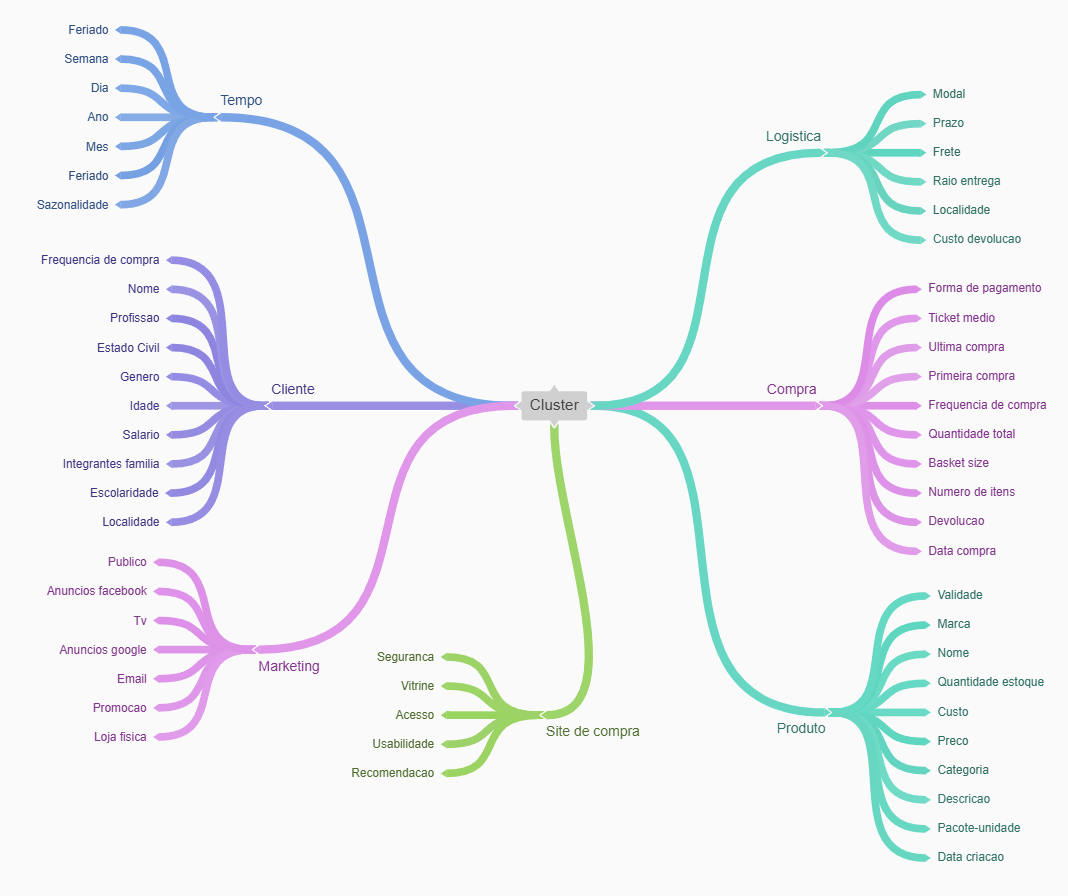

In [82]:
from IPython.display import Image, display

display(Image(filename='../img/mindmap_business.png'))

## 10.2 Hipoteses de Negocio

In [83]:
df_analysis = df51.copy()

# identifica champions
champion_cluster = df_rank_embedding.iloc[0]['cluster']

df_analysis['is_champion'] = df_analysis['cluster'] == champion_cluster

### **H1. Clientes Rankers representam menos de 20% da base, mas geram mais de 60% da receita.**



**Metric:** % clientes = 25.98% | % receita = 76.14%  

**Result:** Partially Confirmed  

---


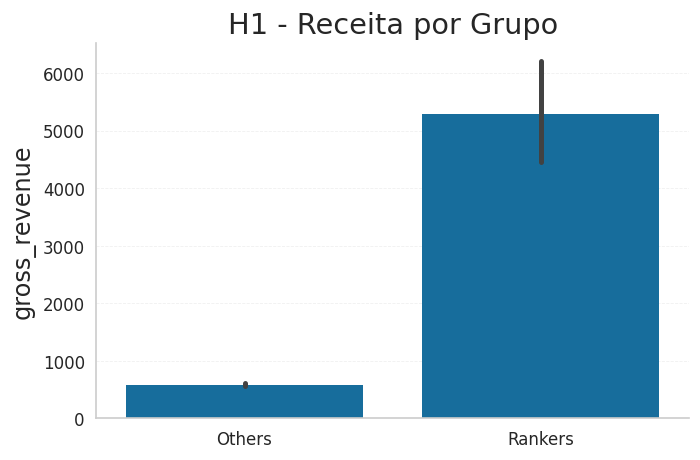

In [84]:
#
total_customers = df_analysis['customer_id'].nunique()
champ_customers = df_analysis[df_analysis['is_champion']]['customer_id'].nunique()

total_revenue = df_analysis['gross_revenue'].sum()
champ_revenue = df_analysis[df_analysis['is_champion']]['gross_revenue'].sum()

perc_customers = champ_customers / total_customers
perc_revenue = champ_revenue / total_revenue

# Output Ajustado
show_hypothesis(
    f"% clientes = {perc_customers:.2%} | % receita = {perc_revenue:.2%}",
    "Confirmed" if perc_revenue > 0.6 and perc_customers < 0.2 else "Partially Confirmed"
)

plot_compare(df_analysis, 'gross_revenue', 'H1 - Receita por Grupo')

### **H2. A frequência de compra tem maior impacto na diferenciação dos Rankers do que o ticket médio.**



**Metric:** Freq ratio = 4.14 | Ticket ratio = 1.98  

**Result:** Confirmed  

---


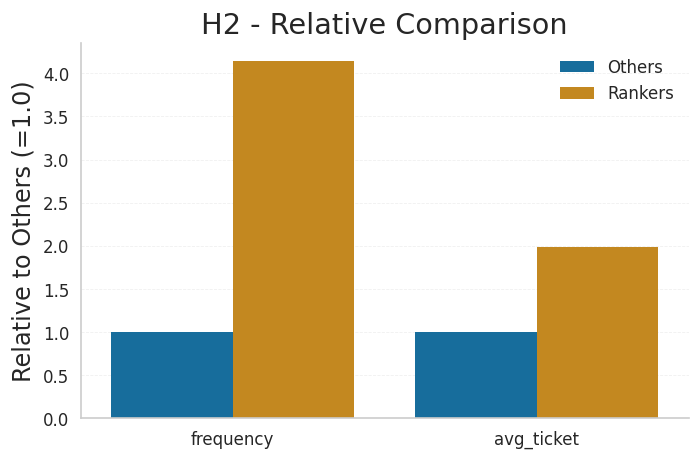

In [85]:
#
group = df_analysis.groupby('is_champion')[['frequency', 'avg_ticket']].mean()

freq_diff = group.loc[True, 'frequency'] / group.loc[False, 'frequency']
ticket_diff = group.loc[True, 'avg_ticket'] / group.loc[False, 'avg_ticket']

show_hypothesis(
    
    f"Freq ratio = {freq_diff:.2f} | Ticket ratio = {ticket_diff:.2f}",
    "Confirmed" if freq_diff > ticket_diff else "Not Confirmed"
)

# normalizar relativo ao grupo "Others"
normalized = group / group.loc[False]

normalized = normalized.reset_index().melt(id_vars='is_champion')

plt.figure(figsize=(6,4))
sns.barplot(data=normalized, x='variable', y='value', hue='is_champion', hue_order=[False, True])

plt.title('H2 - Relative Comparison')
plt.ylabel('Relative to Others (=1.0)')
plt.xlabel('')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Others', 'Rankers'], title='')
plt.tight_layout()
plt.show()

### **H3. Clientes Rankers possuem menor recência, indicando maior probabilidade de recompra.**



**Metric:** Rankers = 36.6 | Outros = 111.8  

**Result:** Confirmed  

---


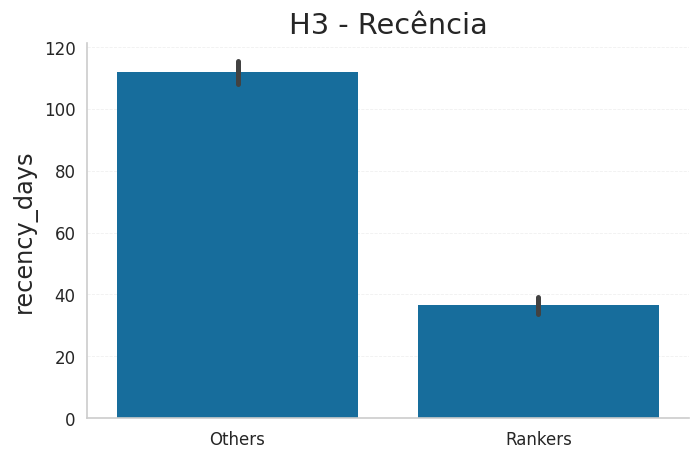

In [86]:
#
group = df_analysis.groupby('is_champion')['recency_days'].mean()

show_hypothesis(
    
    f"Rankers = {group[True]:.1f} | Outros = {group[False]:.1f}",
    "Confirmed" if group[True] < group[False] else "Not Confirmed"
)

plot_compare(df_analysis, 'recency_days', 'H3 - Recência')

### **H4. Clientes Rankers compram maior variedade de produtos, o que está associado a maior valor gerado.**



**Metric:** Rankers = 120.6 | Outros = 34.2  

**Result:** Confirmed  

---


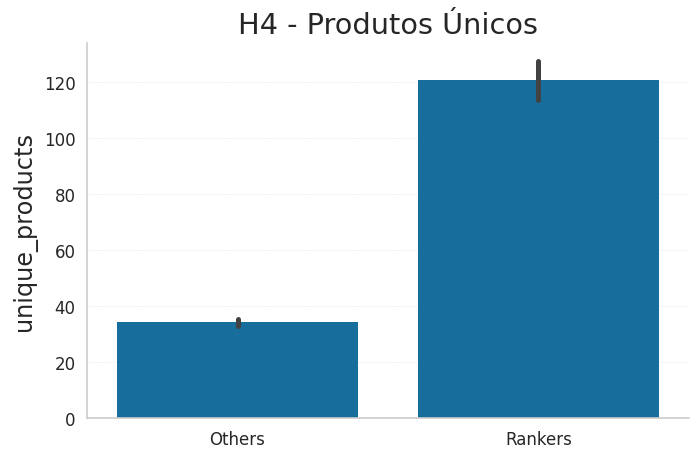

In [87]:
#
group = df_analysis.groupby('is_champion')['unique_products'].mean()

show_hypothesis(
    
    f"Rankers = {group[True]:.1f} | Outros = {group[False]:.1f}",
    "Confirmed" if group[True] > group[False] else "Not Confirmed"
)

plot_compare(df_analysis, 'unique_products', 'H4 - Produtos Únicos')

### **H5. O alto valor dos Rankers é explicado pela combinação de múltiplas variáveis comportamentais, e não por uma única métrica isolada.**



**Metric:**              frequency  recency_days  unique_products
is_champion                                          
False         2.330924    111.765242        34.180075
True          9.655327     36.571173       120.619517  

**Result:** Confirmed  

---


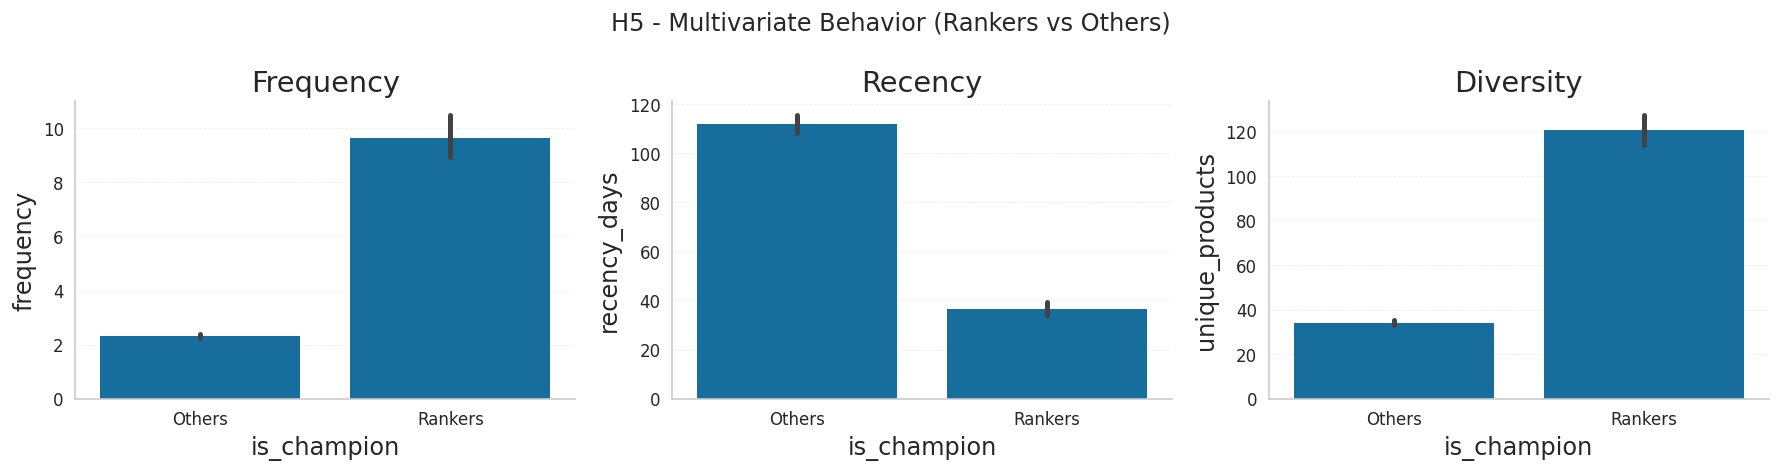

In [88]:
#
group = df_analysis.groupby('is_champion')[['frequency','recency_days','unique_products']].mean()

conditions = [
    group.loc[True, 'frequency'] > group.loc[False, 'frequency'],
    group.loc[True, 'recency_days'] < group.loc[False, 'recency_days'],
    group.loc[True, 'unique_products'] > group.loc[False, 'unique_products']
]

show_hypothesis(
    
    str(group),
    "Confirmed" if all(conditions) else "Partially"
)

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.barplot(data=df_analysis, x='is_champion', y='frequency', ax=axes[0])
axes[0].set_title('Frequency')

sns.barplot(data=df_analysis, x='is_champion', y='recency_days', ax=axes[1])
axes[1].set_title('Recency')

sns.barplot(data=df_analysis, x='is_champion', y='unique_products', ax=axes[2])
axes[2].set_title('Diversity')

for ax in axes:
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Others','Rankers'])

plt.suptitle('H5 - Multivariate Behavior (Rankers vs Others)')
plt.tight_layout()
plt.show()

### **H6. Rankers possuem maior velocidade de geração de receita ao longo do tempo.**



**Metric:** Rankers = 76.38 | Outros = 171.72  

**Result:** Not Confirmed  

---


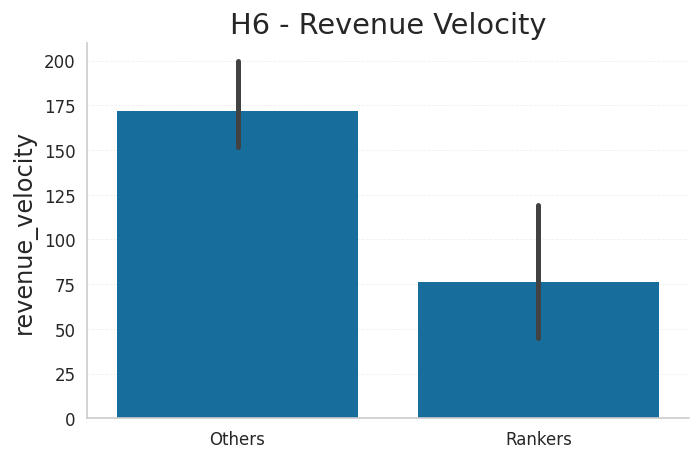

In [89]:
#
group = df_analysis.groupby('is_champion')['revenue_velocity'].mean()

show_hypothesis(
    
    f"Rankers = {group[True]:.2f} | Outros = {group[False]:.2f}",
    "Confirmed" if group[True] > group[False] else "Not Confirmed"
)

plot_compare(df_analysis, 'revenue_velocity', 'H6 - Revenue Velocity')

### **H7. Clientes com menor taxa de devolução tendem a gerar maior receita.**



**Metric:** Rankers = 0.113 | Outros = 0.089  

**Result:** Not Confirmed  

---


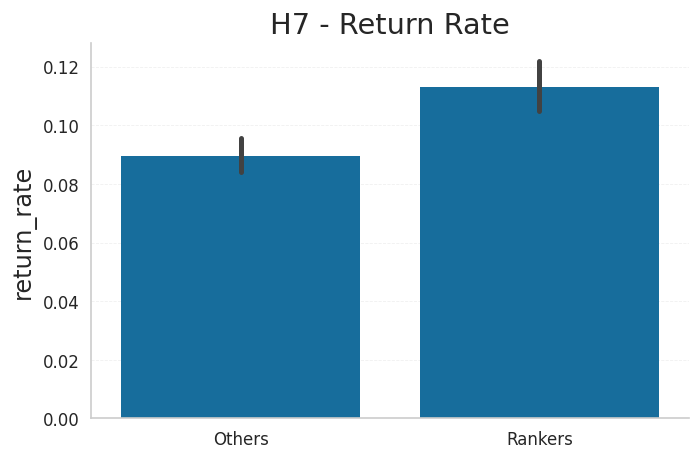

In [90]:
#
group = df_analysis.groupby('is_champion')['return_rate'].mean()

show_hypothesis(
    
    f"Rankers = {group[True]:.3f} | Outros = {group[False]:.3f}",
    "Confirmed" if group[True] < group[False] else "Not Confirmed"
)

plot_compare(df_analysis, 'return_rate', 'H7 - Return Rate')

## 10.3 Quadro final de Respostas

In [91]:
# Seleção da base oficial
df_participants = df_analysis[['customer_id', 'is_champion']].copy()

# Ajuste de nomenclatura para negócio
df_participants['is_ranker'] = df_participants['is_champion'].apply(
    lambda x: 'Sim' if x else 'Não'
)

# Mantém apenas colunas finais
df_participants = df_participants[['customer_id', 'is_ranker']]

df_participants.head()

,customer_id,is_ranker
0,17850,Não
1,13047,Sim
2,12583,Sim
3,13748,Não
4,15100,Não


In [92]:
df_rankers = df_analysis[df_analysis['is_champion'] == True]

n_rankers = df_rankers.shape[0]
total_clients = df_analysis.shape[0]

pct_rankers = (n_rankers / total_clients) * 100

print(f'Clientes Rankers: {n_rankers}')
print(f'% da base: {pct_rankers:.2f}%')
df_rankers

Clientes Rankers: 1117
% da base: 25.98%


,customer_id,gross_revenue,recency_days,frequency,avg_ticket,customer_lifetime_days,revenue_velocity,total_items,items_velocity,basket_size,unique_products,product_loyalty,avg_recency_days,return_value,return_orders,return_rate,return_value_ratio,net_revenue,cluster,is_champion
1,13047,3125.79,56,9,347.310000,317,9.860536,1304,3.757925,144.888889,102,12.784314,1.921212,140.54,7.0,0.437500,0.044961,2985.25,2,True
2,12583,6705.38,2,15,447.025333,371,18.073801,5028,12.538653,335.200000,114,44.105263,1.606061,76.04,2.0,0.117647,0.011340,6629.34,2,True
5,15291,4515.40,25,14,322.528571,348,12.975287,2040,5.396825,145.714286,58,35.172414,3.625000,36.30,4.0,0.222222,0.008039,4479.10,2,True
6,14688,5075.93,7,21,241.710952,366,13.868661,3215,8.118687,153.095238,126,25.515873,1.257732,473.57,6.0,0.222222,0.093297,4602.36,2,True
7,17809,5305.71,16,12,442.142500,357,14.861933,2021,5.222222,168.416667,44,45.931818,6.155172,67.06,2.0,0.142857,0.012639,5238.65,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4082,12985,1160.60,0,2,580.300000,28,41.450000,1471,25.362069,735.500000,68,21.632353,0.400000,23.76,1.0,0.333333,0.020472,1136.84,2,True
4099,14904,983.76,2,2,491.880000,23,42.772174,1897,35.792453,948.500000,61,31.098361,0.365079,0.00,0.0,0.000000,0.000000,983.76,2,True
4191,18139,8438.34,17,6,1406.390000,1,8438.340000,5557,179.258065,926.166667,35,158.771429,0.006329,0.00,0.0,0.000000,0.000000,8438.34,2,True
4192,15274,716.57,4,2,358.285000,14,51.183571,619,14.068182,309.500000,44,14.068182,0.304348,0.00,0.0,0.000000,0.000000,716.57,2,True


In [93]:
# ================================
# 1. Feature: Expected Revenue
# ================================

# Projeção 30 dias
df_analysis['expected_revenue_30d'] = (
    df_analysis['revenue_velocity'] * 30
)

# Peso de recência (quanto mais recente, maior o peso)
df_analysis['recency_weight'] = np.exp(-df_analysis['recency_days'] / 30)

# Projeção ajustada
df_analysis['expected_revenue_30d_adj'] = (
    df_analysis['expected_revenue_30d'] * df_analysis['recency_weight']
)

# ================================
# 2. Preparação dos dados
# ================================
rankers = df_analysis[df_analysis['is_champion'] == True].copy()
others = df_analysis[df_analysis['is_champion'] == False].copy()

# ================================
# 3. Cálculos principais
# ================================
total_revenue = df_analysis['gross_revenue'].sum()
rankers_revenue = rankers['gross_revenue'].sum()
perc_revenue = rankers_revenue / total_revenue

basket_p50 = rankers['basket_size'].median()

# Thresholds (baseados no comportamento dos rankers)
recency_threshold = rankers['recency_days'].quantile(0.75)
revenue_threshold = rankers['gross_revenue'].quantile(0.25)
frequency_threshold = rankers['frequency'].quantile(0.50)

# Thresholds de remoção
return_rate_threshold = rankers['return_rate'].quantile(0.75)
recency_removal_threshold = rankers['recency_days'].quantile(0.85)
frequency_removal_threshold = rankers['frequency'].quantile(0.25)

# ================================
# 4. Relatório
# ================================
report_text = f"""
# 2️⃣ Relatório Executivo: Programa Rankers

---

## 1. Resumo de Performance (Rankers vs Base)

O grupo **Rankers** apresenta desempenho significativamente superior em todas as métricas de valor.

| Métrica | Rankers (Média) | Restante da Base | Diferença |
| :--- | :--- | :--- | :--- |
| **Faturamento** | R$ {rankers['gross_revenue'].mean():,.2f} | R$ {others['gross_revenue'].mean():,.2f} | **{rankers['gross_revenue'].mean()/others['gross_revenue'].mean():.1f}x maior** |
| **Frequência** | {rankers['frequency'].mean():.1f} | {others['frequency'].mean():.1f} | **{rankers['frequency'].mean()/others['frequency'].mean():.1f}x maior** |
| **Recência** | {rankers['recency_days'].mean():.1f} dias | {others['recency_days'].mean():.1f} dias | **{others['recency_days'].mean()/max(1, rankers['recency_days'].mean()):.1f}x mais ativo** |
| **Mix de Produtos** | {rankers['unique_products'].mean():.0f} | {others['unique_products'].mean():.0f} | **{rankers['unique_products'].mean()/others['unique_products'].mean():.1f}x maior** |

---

## 2. Respostas às Perguntas de Negócio

**Quem são as pessoas elegíveis?**  
Clientes com alto valor de compra, alta frequência e comportamento recente, com baixo índice de devolução (*return_rate médio de {rankers['return_rate'].mean():.1%}*).

**Quantos clientes fazem parte?**  
O programa conta com **{len(rankers)} clientes**, representando uma parcela estratégica da base.

**Qual a contribuição no faturamento?**  
Os Rankers são responsáveis por **{perc_revenue:.1%} da receita total**, evidenciando forte concentração de valor.

**Qual a expectativa de faturamento (30 dias)?**  
A projeção indica **R$ {rankers['expected_revenue_30d_adj'].sum():,.2f}** em receita no próximo mês, considerando a velocidade histórica de geração de receita ajustada pelo nível atual de atividade dos clientes.

A diferença em relação a uma projeção não ajustada indica que parte relevante do faturamento potencial está concentrada em clientes com menor engajamento recente, evidenciando risco de superestimação sem controle de recência.

**Qual a garantia de que o grupo é superior?**  
Os Rankers apresentam desempenho consistente superior:

- **{rankers['frequency'].mean()/others['frequency'].mean():.1f}x mais compras**
- **{rankers['gross_revenue'].mean()/others['gross_revenue'].mean():.1f}x mais faturamento**
- **Menor recência média (maior atividade recente)**

Esse desempenho demonstra que o grupo concentra clientes com alto valor de ciclo de vida (LTV), maior recorrência e maior previsibilidade de receita.

---

## 3. Regras de Manutenção e Gestão

As regras abaixo foram definidas com base na distribuição dos próprios clientes Rankers, garantindo aderência ao comportamento real do grupo.

**Condição de Elegibilidade:**
- Faturamento superior a **R$ {revenue_threshold:,.2f}**
- Recência inferior a **{recency_threshold:.0f} dias**
- Frequência acima de **{frequency_threshold:.1f} compras**

**Condição de Remoção:**
- `return_rate` superior a **{return_rate_threshold:.2%}**
- `recency_days` superior a **{recency_removal_threshold:.0f} dias**
- `frequency` inferior a **{frequency_removal_threshold:.1f} compras**

**Ação de Marketing Recomendada:**

Dado o alto nível de recorrência e volume de compras, a estratégia deve priorizar:

- Aumento de frequência: estímulos de recompra em janelas curtas
- Expansão de ticket: bundles e ofertas por volume
- Retenção ativa: benefícios exclusivos e programas de fidelidade

Adicionalmente, recomenda-se monitorar clientes com queda de frequência para ações preventivas de retenção.

---

## 🧠 Conclusão

Os Rankers representam o principal motor de geração de receita da base, combinando alto volume, recorrência e previsibilidade de consumo.

A ativação de estratégias direcionadas a esse grupo permite maximizar o retorno com baixo custo incremental, ao mesmo tempo em que reduz riscos de perda de receita através de ações preventivas.

Dessa forma, o programa Rankers se posiciona como uma alavanca direta de crescimento e eficiência operacional.

---
"""

display(Markdown(report_text))


# 2️⃣ Relatório Executivo: Programa Rankers

---

## 1. Resumo de Performance (Rankers vs Base)

O grupo **Rankers** apresenta desempenho significativamente superior em todas as métricas de valor.

| Métrica | Rankers (Média) | Restante da Base | Diferença |
| :--- | :--- | :--- | :--- |
| **Faturamento** | R$ 5,291.29 | R$ 582.13 | **9.1x maior** |
| **Frequência** | 9.7 | 2.3 | **4.1x maior** |
| **Recência** | 36.6 dias | 111.8 dias | **3.1x mais ativo** |
| **Mix de Produtos** | 121 | 34 | **3.5x maior** |

---

## 2. Respostas às Perguntas de Negócio

**Quem são as pessoas elegíveis?**  
Clientes com alto valor de compra, alta frequência e comportamento recente, com baixo índice de devolução (*return_rate médio de 11.3%*).

**Quantos clientes fazem parte?**  
O programa conta com **1117 clientes**, representando uma parcela estratégica da base.

**Qual a contribuição no faturamento?**  
Os Rankers são responsáveis por **76.1% da receita total**, evidenciando forte concentração de valor.

**Qual a expectativa de faturamento (30 dias)?**  
A projeção indica **R$ 1,002,064.39** em receita no próximo mês, considerando a velocidade histórica de geração de receita ajustada pelo nível atual de atividade dos clientes.

A diferença em relação a uma projeção não ajustada indica que parte relevante do faturamento potencial está concentrada em clientes com menor engajamento recente, evidenciando risco de superestimação sem controle de recência.

**Qual a garantia de que o grupo é superior?**  
Os Rankers apresentam desempenho consistente superior:

- **4.1x mais compras**
- **9.1x mais faturamento**
- **Menor recência média (maior atividade recente)**

Esse desempenho demonstra que o grupo concentra clientes com alto valor de ciclo de vida (LTV), maior recorrência e maior previsibilidade de receita.

---

## 3. Regras de Manutenção e Gestão

As regras abaixo foram definidas com base na distribuição dos próprios clientes Rankers, garantindo aderência ao comportamento real do grupo.

**Condição de Elegibilidade:**
- Faturamento superior a **R$ 1,610.16**
- Recência inferior a **49 dias**
- Frequência acima de **6.0 compras**

**Condição de Remoção:**
- `return_rate` superior a **20.00%**
- `recency_days` superior a **73 dias**
- `frequency` inferior a **4.0 compras**

**Ação de Marketing Recomendada:**

Dado o alto nível de recorrência e volume de compras, a estratégia deve priorizar:

- Aumento de frequência: estímulos de recompra em janelas curtas
- Expansão de ticket: bundles e ofertas por volume
- Retenção ativa: benefícios exclusivos e programas de fidelidade

Adicionalmente, recomenda-se monitorar clientes com queda de frequência para ações preventivas de retenção.

---

## 🧠 Conclusão

Os Rankers representam o principal motor de geração de receita da base, combinando alto volume, recorrência e previsibilidade de consumo.

A ativação de estratégias direcionadas a esse grupo permite maximizar o retorno com baixo custo incremental, ao mesmo tempo em que reduz riscos de perda de receita através de ações preventivas.

Dessa forma, o programa Rankers se posiciona como uma alavanca direta de crescimento e eficiência operacional.

---


# 11 - Deploy

In [94]:
df51.dtypes

customer_id                 int64
gross_revenue             float64
recency_days                int64
frequency                   int64
avg_ticket                float64
customer_lifetime_days      int64
revenue_velocity          float64
total_items                 int64
items_velocity            float64
basket_size               float64
unique_products             int64
product_loyalty           float64
avg_recency_days          float64
return_value              float64
return_orders             float64
return_rate               float64
return_value_ratio        float64
net_revenue               float64
cluster                     int32
dtype: object

In [95]:
df51['customer_id'] = df51['customer_id'].astype(int)
df51['return_orders'] = df51['return_orders'].astype(int)
df51['cluster'] = df51['cluster'].astype(int)

In [ ]:

# conexão
conn = create_engine('sqlite:////mnt/c/Users/carlo/OneDrive/repos/pa005_ecommerce/data/db/customer_segmentation.sqlite')

# queries
query_drop_rankers = """
DROP TABLE IF EXISTS rankers;
"""

query_create_rankers = """
CREATE TABLE rankers (
    customer_id INTEGER,
    gross_revenue REAL,
    recency_days INTEGER,
    frequency INTEGER,
    avg_ticket REAL,
    customer_lifetime_days INTEGER,
    revenue_velocity REAL,
    total_items INTEGER,
    items_velocity REAL,
    basket_size REAL,
    unique_products INTEGER,
    product_loyalty REAL,
    avg_recency_days REAL,
    return_value REAL,
    return_orders INTEGER,
    return_rate REAL,
    return_value_ratio REAL,
    net_revenue REAL,
    cluster INTEGER,
    is_champion INTEGER
);
"""

# executa SQL
with conn.connect() as connection:
    connection.execute(text(query_drop_rankers))
    connection.execute(text(query_create_rankers))

# insere dados
df51.to_sql('rankers', con=conn, if_exists='replace', index=False)

4299

In [97]:
# coleta dados
query_collect = """
SELECT * FROM rankers;
"""

df_test = pd.read_sql_query(query_collect, conn)
df_test.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,customer_lifetime_days,revenue_velocity,total_items,items_velocity,basket_size,unique_products,product_loyalty,avg_recency_days,return_value,return_orders,return_rate,return_value_ratio,net_revenue,cluster
0,17850,3689.25,372,34,108.507353,1,3689.250000,1169,37.709677,34.382353,15,77.933333,0.004739,66.88,1,0.028571,0.018128,3622.37,4
1,13047,3125.79,56,9,347.310000,317,9.860536,1304,3.757925,144.888889,102,12.784314,1.921212,140.54,7,0.437500,0.044961,2985.25,2
2,12583,6705.38,2,15,447.025333,371,18.073801,5028,12.538653,335.200000,114,44.105263,1.606061,76.04,2,0.117647,0.011340,6629.34,2
3,13748,948.25,95,5,189.650000,278,3.410971,439,1.425325,87.800000,24,18.291667,10.296296,0.00,0,0.000000,0.000000,948.25,0
4,15100,876.00,333,3,292.000000,40,21.900000,80,1.142857,26.666667,1,80.000000,20.000000,240.90,3,0.500000,0.275000,635.10,3
